# Load Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Latency tracking
import time
_pipeline_times = {}
_section_start  = {}

def section_start(name):
    _section_start[name] = time.time()
    print(f"[START] {name}")

def section_end(name):
    elapsed = time.time() - _section_start[name]
    _pipeline_times[name] = elapsed
    print(f"[END]   {name} — {elapsed:.1f}s")

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load dataset
dataset = fetch_ucirepo(id=967)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

In [ ]:
X = df.drop(columns=['label'])
y = df[['label']]

# fixing types
binary_cols = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]

df[binary_cols] = df[binary_cols].astype('category')
df['label'] = df['label'].astype('category')

categorical_df = X.select_dtypes(include='category') #### NOTICE: categorical_df is built from X only ----> for label use y!!!!!
numeric_df = X.drop(columns=categorical_df.columns)

In [ ]:
section_start("data_loading")
print(f"df shape: {df.shape}")
section_end("data_loading")

[START] data_loading
df shape: (235795, 55)
[END]   data_loading — 0.0s


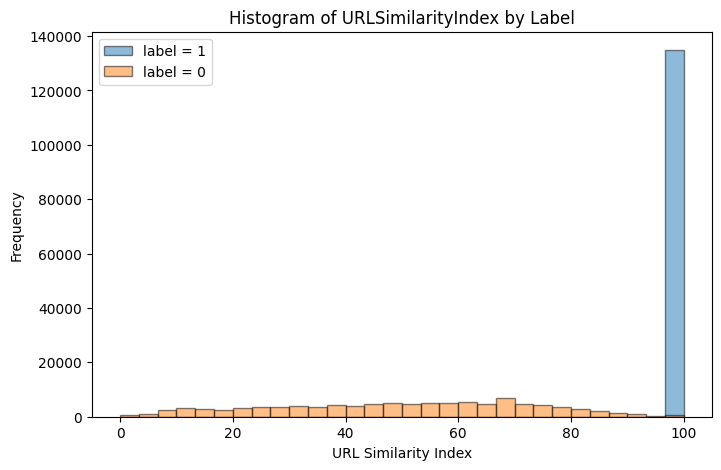

In [ ]:
# primary motivation for our analysis of usi vs no usi

bins = np.linspace(0, 100, 31) # 30 equal-width bins from 0-100

plt.figure(figsize=(8, 5))

for label in df["label"].unique():
  subset = df[df["label"] == label]
  plt.hist(
    subset["URLSimilarityIndex"],
    bins=bins,
    alpha=0.5,
    label=f"label = {label}",
    edgecolor="black"
  )

plt.xlabel("URL Similarity Index")
plt.ylabel("Frequency")
plt.title("Histogram of URLSimilarityIndex by Label")
plt.legend()
plt.show()

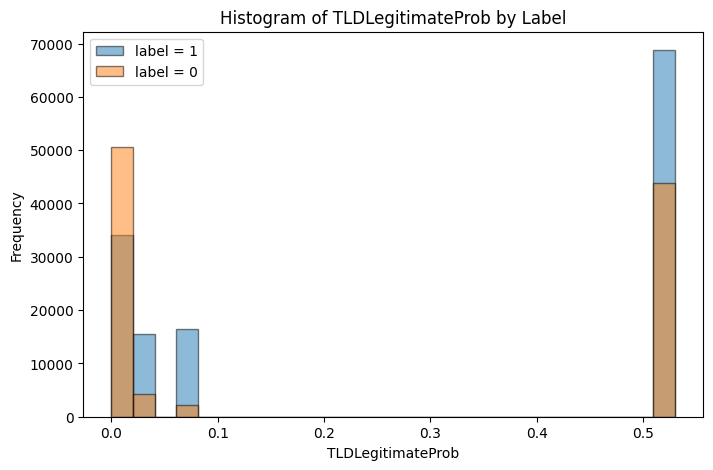

In [ ]:
bins = np.linspace(0, 0.53, 27)

plt.figure(figsize=(8, 5))

for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.hist(
        subset["TLDLegitimateProb"],
        bins=bins,
        alpha=0.5,
        label=f"label = {label}",
        edgecolor="black"
    )

plt.xlabel("TLDLegitimateProb")
plt.ylabel("Frequency")
plt.title("Histogram of TLDLegitimateProb by Label")
plt.legend()
plt.show()

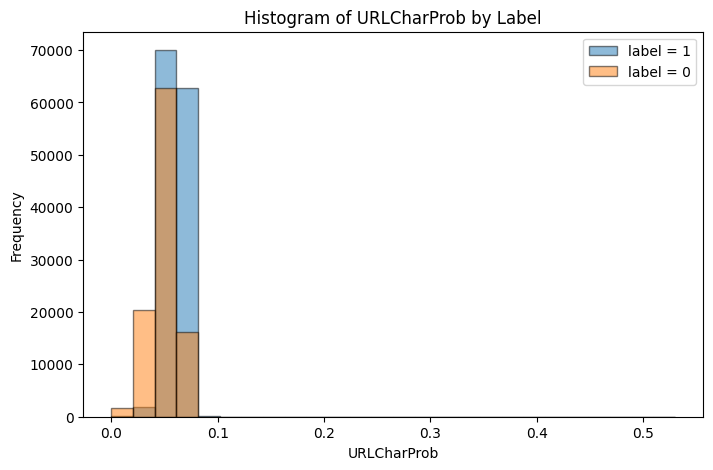

In [ ]:
bins = np.linspace(0, 0.53, 27)

plt.figure(figsize=(8, 5))

for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.hist(
        subset["URLCharProb"],
        bins=bins,
        alpha=0.5,
        label=f"label = {label}",
        edgecolor="black"
    )

plt.xlabel("URLCharProb")
plt.ylabel("Frequency")
plt.title("Histogram of URLCharProb by Label")
plt.legend()
plt.show()

# Data Cleaning

In [ ]:
# how many missing values are in each column?
missing = df.isna().sum() # count NaNs per column
missing = missing[missing > 0].sort_values(ascending=False) # only show ones that actually have missing
if len(missing):
  print("Columns with missing values:")
  print(missing)
else:
  print("No NaN values anywhere")

# isna() doesn't catch empty/whitespace strings, so we check those separately for the object columns
for col in df.select_dtypes(include='object').columns:
  n_blank = df[col].astype(str).str.strip().eq('').sum() # count rows that are '' after stripping
  if n_blank:
    print(f"{col}: {n_blank} blank/whitespace-only strings")

No NaN values anywhere


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   URL                         235795 non-null  object  
 1   URLLength                   235795 non-null  int64   
 2   Domain                      235795 non-null  object  
 3   DomainLength                235795 non-null  int64   
 4   IsDomainIP                  235795 non-null  category
 5   TLD                         235795 non-null  object  
 6   URLSimilarityIndex          235795 non-null  float64 
 7   CharContinuationRate        235795 non-null  float64 
 8   TLDLegitimateProb           235795 non-null  float64 
 9   URLCharProb                 235795 non-null  float64 
 10  TLDLength                   235795 non-null  int64   
 11  NoOfSubDomain               235795 non-null  int64   
 12  HasObfuscation              235795 non-null  category
 13 

In [ ]:
section_start("data_cleaning")

# duplicate detection: every URL is unique bc it's like a primary key
# so we check if any two rows are duplicate IF we ignore URL since these are same site fetched twice and could leak across train/test if undropped
n_dup_full   = df.duplicated().sum() # exact duplicates (URL included)
n_dup_no_url = df.drop(columns=['URL']).duplicated().sum() # duplicates ignoring URL
print(f"Exact duplicate rows: {n_dup_full}")
print(f"Duplicates ignoring URL col: {n_dup_no_url}")

# drop the ignore-URL duplicates --> keep the first occurrence
before = len(df)
df = df.drop_duplicates(subset=df.columns.difference(['URL'])).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows --> remaining: {len(df)}")

# rebuild the helper frames so the later cells use the cleaned df
X = df.drop(columns=['label']) # features only
y = df[['label']] # target only
categorical_df = X.select_dtypes(include='category') # any category-typed cols (binary flags)
numeric_df = X.drop(columns=categorical_df.columns) # everything else (numeric + the 4 string cols)

section_end("data_cleaning")

[START] data_cleaning
Exact duplicate rows: 0
Duplicates ignoring URL col: 91
Dropped 91 rows --> remaining: 235704
[END]   data_cleaning — 15.9s


### Train/Val/Test Split to avoid Leakage

In [ ]:
section_start("train_val_test_split")
from sklearn.model_selection import train_test_split

# stratified 70/15/15 split
y_full = (df['label'] == 0).astype(int).values # 1 = phishing, 0 = legit
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y_full, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y_full[idx_temp], random_state=42)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val = df.iloc[idx_val].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

# targets (1 = phishing, 0 = legit)
y_train = (df_train['label'] == 0).astype(int).values
y_val = (df_val['label'] == 0).astype(int).values
y_test = (df_test['label'] == 0).astype(int).values

# features (without label) (these will get transformed step by step)
X_train = df_train.drop(columns=['label']).copy()
X_val = df_val.drop(columns=['label']).copy()
X_test = df_test.drop(columns=['label']).copy()

print(f"train: {len(df_train):>7d} ({y_train.mean():.2%} phishing)")
print(f"val: {len(df_val):>7d} ({y_val.mean():.2%} phishing)")
print(f"test: {len(df_test):>7d} ({y_test.mean():.2%} phishing)")
section_end("train_val_test_split")

[START] train_val_test_split
train:  164992 (42.79% phishing)
val:   35356 (42.79% phishing)
test:   35356 (42.79% phishing)
[END]   train_val_test_split — 5.6s


In [ ]:
# outlier detection: flag rows with at least one feature more than 3 std devs from the mean (3-sigma rule)
from scipy.stats import zscore

num_only = df_train.drop(columns=['label']).select_dtypes(include=[np.number]) # int/float only i.e. skip URL/Domain/TLD/Title
z = np.abs(zscore(num_only, nan_policy='omit')) # absolute z-score per cell
extreme_rows = (z > 3).any(axis=1) # row is "extreme" if ANY feature is past |z|>3
print(f"Rows with at least one |z|>3 feature: {extreme_rows.sum()} ({extreme_rows.mean():.2%})")

Rows with at least one |z|>3 feature: 25208 (15.28%)


Phishing rate (overall): 42.79%
Phishing rate among |z|>3 outlier rows: 63.35%
Phishing rate among non-outlier rows: 39.08%
Lift among outliers: 1.48x

Phishing rate by max |z|-score bucket:
         mean   count
bucket               
0-1     0.145      62
1-2     0.340  111516
2-3     0.592   28206
3-5     0.565   14887
5+      0.732   10321


/tmp/ipykernel_8287/3125286999.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phish_by_bucket = (pd.DataFrame({'bucket': buckets, 'is_phish': (df_train['label']==0).astype(int).values}).groupby('bucket')['is_phish'].agg(['mean', 'count']))


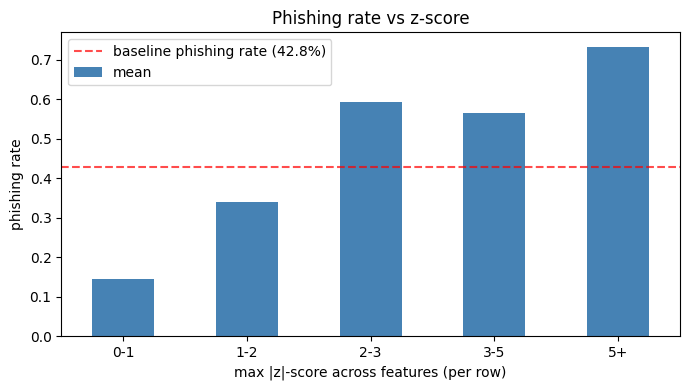

In [ ]:
# proof that outliers actually contain phishing signal and aren't just noise to drop
# i.e. compare phishing rates among outlier rows vs. non-outlier rows.

phish_overall = (df_train['label'] == 0).mean() # baseline phishing rate
phish_outliers = (df_train.loc[extreme_rows, 'label'] == 0).mean() # phishing rate among |z|>3 rows
phish_normal = (df_train.loc[~extreme_rows, 'label'] == 0).mean() # phishing rate among the rest

print(f"Phishing rate (overall): {phish_overall:.2%}")
print(f"Phishing rate among |z|>3 outlier rows: {phish_outliers:.2%}")
print(f"Phishing rate among non-outlier rows: {phish_normal:.2%}")
print(f"Lift among outliers: {phish_outliers / phish_overall:.2f}x")

# bucket rows by the maximum |z|-score across features and plot phishing rate per bucket
# if phishing rate climbs as rows get more extreme, outliers are signal, not noise
zmax = z.max(axis=1) # max |z| per row
buckets = pd.cut(zmax, bins=[0, 1, 2, 3, 5, np.inf], labels=['0-1', '1-2', '2-3', '3-5', '5+'])
phish_by_bucket = (pd.DataFrame({'bucket': buckets, 'is_phish': (df_train['label']==0).astype(int).values}).groupby('bucket')['is_phish'].agg(['mean', 'count']))
print(f"\nPhishing rate by max |z|-score bucket:")
print(phish_by_bucket.round(3))

# bar chart with baseline marked -- the steeper the climb, the more signal in the outliers
fig, ax = plt.subplots(figsize=(7, 4))
phish_by_bucket['mean'].plot(kind='bar', color='steelblue', ax=ax)
ax.axhline(phish_overall, color='red', linestyle='--', alpha=0.7,
           label=f'baseline phishing rate ({phish_overall:.1%})')
ax.set_xlabel('max |z|-score across features (per row)')
ax.set_ylabel('phishing rate')
ax.set_title('Phishing rate vs z-score')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

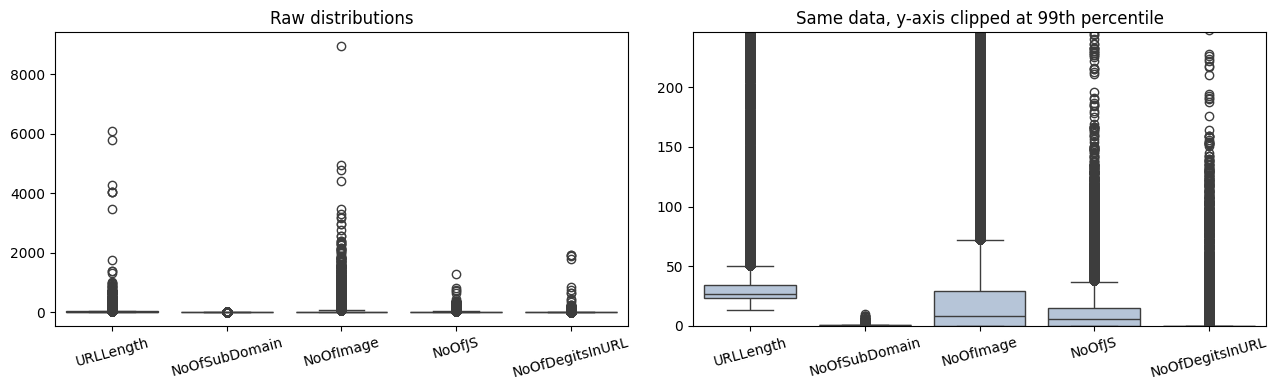

In [ ]:
# boxplot of a few heavy-tailed numeric features
candidates = ['URLLength', 'NoOfSubDomain', 'NoOfImage', 'NoOfJS', 'NoOfDegitsInURL']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# left: raw boxplot
sns.boxplot(data=df_train[candidates], ax=axes[0], color='lightsteelblue')
axes[0].set_title('Raw distributions')
axes[0].tick_params(axis='x', rotation=15)

# right: same data, y-axis clipped at the 99th percentile so typical values become visible
sns.boxplot(data=df_train[candidates], ax=axes[1], color='lightsteelblue')
upper_lim = df_train[candidates].quantile(0.99).max()
axes[1].set_ylim(0, upper_lim)
axes[1].set_title('Same data, y-axis clipped at 99th percentile')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Data Transformation

In [ ]:
from scipy.stats import boxcox, yeojohnson

# numeric columns to transform (excludes URL/Domain/TLD/Title which are objects)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Skew on TRAIN (we fit transformations on train only):")
print(X_train[numeric_cols].skew())

# fit lambdas + z-score statistics on TRAIN, then apply the same parameters to val/test
fitted_lambdas = {} # col -> (method, lambda)
fitted_zscore  = {} # col -> (train_mean, train_std)

for col in numeric_cols:
  train_vals = X_train[col].values
  skew_val   = X_train[col].skew()

  # apply Yeo-Johnson if heavily skewed and contains zeros/negatives;
  # Box-Cox if heavily skewed and strictly positive
  if abs(skew_val) > 1:
    if (train_vals <= 0).any():
      tr_train, lam = yeojohnson(train_vals) # fit lambda on train
      fitted_lambdas[col] = ('yeojohnson', lam)
      tr_val = yeojohnson(X_val[col].values,  lmbda=lam) # apply same lambda
      tr_test = yeojohnson(X_test[col].values, lmbda=lam)
    else:
      tr_train, lam = boxcox(train_vals)
      fitted_lambdas[col] = ('boxcox', lam)
      tr_val = boxcox(X_val[col].values,  lmbda=lam)
      tr_test = boxcox(X_test[col].values, lmbda=lam)
  else:
    # mild skew -- pass through unchanged (still gets z-scored below)
    fitted_lambdas[col] = ('identity', None)
    tr_train, tr_val, tr_test = train_vals, X_val[col].values, X_test[col].values

  # z-score using TRAIN mean / std (btw it will give same result for already-z-scored columns so no negative impact)
  train_mean = tr_train.mean()
  train_std = tr_train.std() if tr_train.std() > 0 else 1.0
  fitted_zscore[col] = (train_mean, train_std)

  X_train[col] = (tr_train - train_mean) / train_std
  X_val[col] = (tr_val   - train_mean) / train_std
  X_test[col] = (tr_test  - train_mean) / train_std

print("\nSkew on TRAIN after transformation:")
print(X_train[numeric_cols].skew())

Skew on TRAIN (we fit transformations on train only):
URLLength                      57.264480
DomainLength                    2.517905
URLSimilarityIndex             -0.991006
CharContinuationRate           -1.132152
TLDLegitimateProb               0.073913
URLCharProb                    -1.063622
TLDLength                       1.632122
NoOfSubDomain                   1.775444
NoOfObfuscatedChar            198.261372
ObfuscationRatio               37.684803
NoOfLettersInURL               65.742963
LetterRatioInURL               -0.064665
NoOfDegitsInURL                92.495384
DegitRatioInURL                 3.255045
NoOfEqualsInURL               115.430154
NoOfQMarkInURL                  8.205854
NoOfAmpersandInURL            105.228828
NoOfOtherSpecialCharsInURL     50.557468
SpacialCharRatioInURL           1.182229
LineOfCode                     55.457678
LargestLineLength              48.807062
DomainTitleMatchScore          -0.012007
URLTitleMatchScore             -0.092324
NoO

In [ ]:
# TLD encoding: top-20 TLDs from TRAIN, bucket the rest as 'OTHER', then one-hot encode
# val/test sets get the same column set even if they contain TLDs not seen in train

TOP_K_TLD = 20
top_tlds = X_train['TLD'].value_counts().head(TOP_K_TLD).index.tolist()
all_categories = top_tlds + ['OTHER']

def encode_tld(df_split, top_tlds, categories):
  out = df_split.copy()
  out['TLD'] = out['TLD'].where(out['TLD'].isin(top_tlds), other='OTHER') # bucket rare TLDs
  out['TLD'] = pd.Categorical(out['TLD'], categories=categories) # lock in the category set
  out = pd.get_dummies(out, columns=['TLD'], prefix='TLD', drop_first=False)
  bool_cols = out.select_dtypes(include='bool').columns
  out[bool_cols] = out[bool_cols].astype(int) # cast bool -> int so select_dtypes(np.number) keeps them
  return out

X_train = encode_tld(X_train, top_tlds, all_categories)
X_val = encode_tld(X_val,   top_tlds, all_categories)
X_test = encode_tld(X_test,  top_tlds, all_categories)

print(f"X_train shape after TLD encoding: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(X_train[numeric_cols].agg(['mean', 'std']).round(3).T.head())

X_train shape after TLD encoding: (164992, 74)
X_val shape: (35356, 74)
X_test shape: (35356, 74)
                      mean  std
URLLength             -0.0  1.0
DomainLength           0.0  1.0
URLSimilarityIndex    -0.0  1.0
CharContinuationRate  -0.0  1.0
TLDLegitimateProb      0.0  1.0


[START] data_transformation


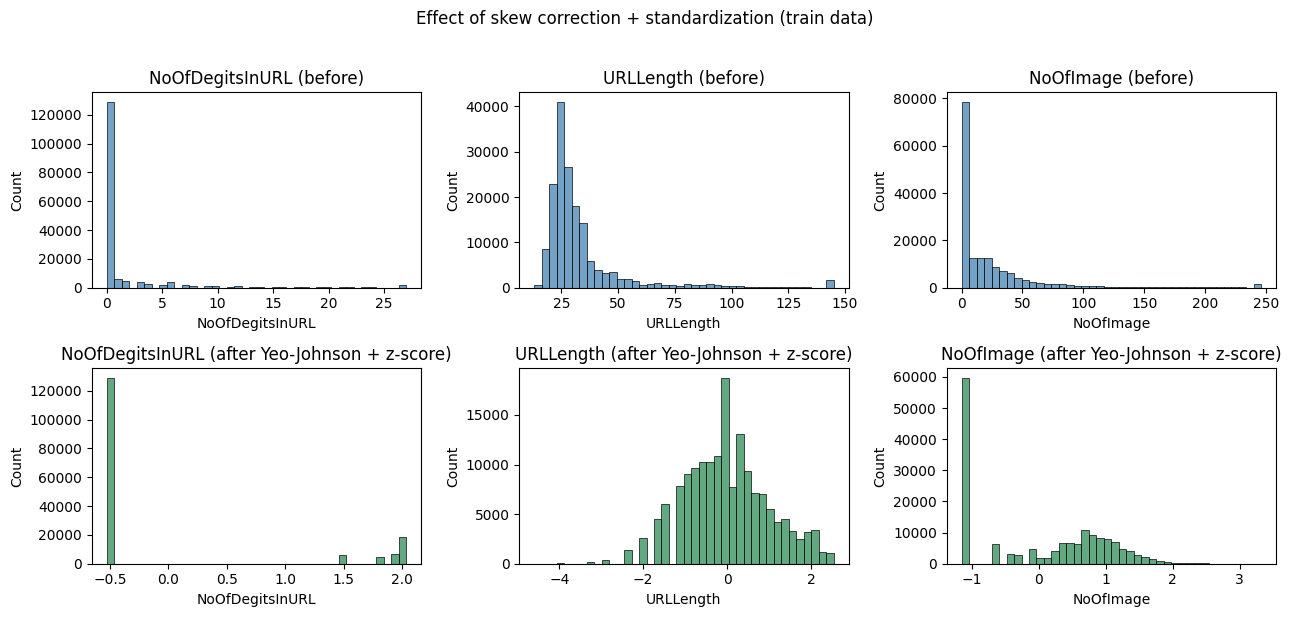

[END]   data_transformation — 5.4s


In [ ]:
section_start("data_transformation")

# histograms before vs. after transformation, calculated on TRAIN only
# df_train still has the pre-transformation values while X_train has the post-transformation z-scored ones

features_to_plot = ['NoOfDegitsInURL', 'URLLength', 'NoOfImage']

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for col_idx, feat in enumerate(features_to_plot):
  # BEFORE: clip at the 99th percentile so the bulk of the distribution is visible
  upper = df_train[feat].quantile(0.99)
  sns.histplot(df_train[feat].clip(upper=upper), bins=40, ax=axes[0, col_idx], color='steelblue')
  axes[0, col_idx].set_title(f'{feat} (before)')

  # AFTER: the transformed + z-scored values from X_train
  sns.histplot(X_train[feat], bins=40, ax=axes[1, col_idx], color='seagreen')
  axes[1, col_idx].set_title(f'{feat} (after Yeo-Johnson + z-score)')

plt.suptitle('Effect of skew correction + standardization (train data)', y=1.02)
plt.tight_layout()
plt.show()

section_end("data_transformation")

# Feature Selection

In [ ]:
# variance threshold: drop features that are essentially constant in original TRAIN data
# IMPORTANT: we read variances from df_train (pre-transform), not X_train (post-transform)
# bc after Yeo-Johnson + z-score, every column has var ~ 1, so a post-transform check is ~ useless
from sklearn.feature_selection import VarianceThreshold

# only do on the numeric/encoded portion of X (skips URL/Domain/Title which are strings)
X_train_numeric = X_train.select_dtypes(include=[np.number]).copy()
X_val_numeric = X_val.select_dtypes(include=[np.number]).copy()
X_test_numeric = X_test.select_dtypes(include=[np.number]).copy()

# look at the original variances on TRAIN
pre_transform_var = df_train.select_dtypes(include=[np.number]).var().sort_values()
print("Five lowest pre-transform variances (train):")
print(pre_transform_var.head().round(6))

# drop columns whose ORIGINAL train variance is below 1e-4 (i.e. roughly constant)
near_constant = pre_transform_var[pre_transform_var < 1e-4].index.tolist()
near_constant = [c for c in near_constant if c in X_train_numeric.columns]

print()
if near_constant:
  print(f"Dropping {len(near_constant)} feature(s) that were near-constant in train:")
  for col in near_constant:
    print(f"--> {col}: original var = {pre_transform_var[col]:.6f}")
  X_train_numeric = X_train_numeric.drop(columns=near_constant)
  X_val_numeric   = X_val_numeric.drop(columns=near_constant)
  X_test_numeric  = X_test_numeric.drop(columns=near_constant)
else:
  print("No features below the variance threshold.")

print(f"Variance threshold: kept {X_train_numeric.shape[1]} features")

Five lowest pre-transform variances (train):
ObfuscationRatio         0.000013
URLCharProb              0.000112
SpacialCharRatioInURL    0.001045
DegitRatioInURL          0.004993
LetterRatioInURL         0.015181
dtype: float64

Dropping 1 feature(s) that were near-constant in train:
--> ObfuscationRatio: original var = 0.000013
Variance threshold: kept 51 features


In [ ]:
# correlation filter: if two features have |r| > 0.95 they carry essentially the same information

corr = X_train_numeric.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # upper triangle only

high_corr = upper.stack().reset_index()
high_corr.columns = ['feature_a', 'feature_b', 'corr']
high_corr = high_corr[high_corr['corr'] > 0.95].sort_values('corr', ascending=False)

print(f"Pairs of features with |r| > 0.95 ({len(high_corr)} pairs):")
for _, row in high_corr.iterrows():
  print(f"r={row['corr']:.3f}: {row['feature_a']:32s} <-> {row['feature_b']}")

# drop one feature from each correlated pair
to_drop_corr = [col for col in upper.columns if (upper[col] > 0.95).any()]
print(f"\nDropping {len(to_drop_corr)} features (one from each pair): {to_drop_corr}")

X_train_numeric = X_train_numeric.drop(columns=to_drop_corr)
X_val_numeric = X_val_numeric.drop(columns=to_drop_corr)
X_test_numeric = X_test_numeric.drop(columns=to_drop_corr)
print(f"Remaining features: {X_train_numeric.shape[1]}")

Pairs of features with |r| > 0.95 (4 pairs):
r=0.997: TLDLegitimateProb                <-> TLD_com
r=0.994: NoOfDegitsInURL                  <-> DegitRatioInURL
r=0.961: DomainTitleMatchScore            <-> URLTitleMatchScore
r=0.953: URLLength                        <-> NoOfLettersInURL

Dropping 4 features (one from each pair): ['NoOfLettersInURL', 'DegitRatioInURL', 'URLTitleMatchScore', 'TLD_com']
Remaining features: 47


In [ ]:
# mutual information ranking on the full TRAIN set
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_numeric, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train_numeric.columns).sort_values(ascending=False)

print("Top 15 features by mutual information (train):")
print(mi_series.head(15).round(4))

Top 15 features by mutual information (train):
URLSimilarityIndex            0.6718
LineOfCode                    0.6009
NoOfExternalRef               0.5647
NoOfImage                     0.5494
NoOfSelfRef                   0.5332
NoOfJS                        0.5069
LargestLineLength             0.4858
NoOfCSS                       0.4526
LetterRatioInURL              0.3808
NoOfOtherSpecialCharsInURL    0.2426
DomainTitleMatchScore         0.2050
SpacialCharRatioInURL         0.2048
TLDLegitimateProb             0.1863
NoOfDegitsInURL               0.1788
NoOfEmptyRef                  0.1742
dtype: float64


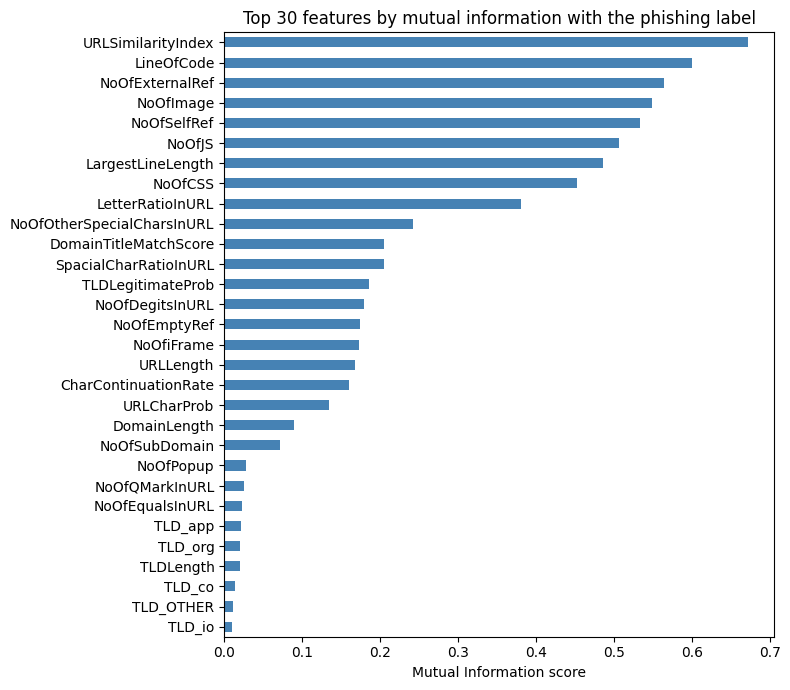

In [ ]:
# bar chart of top-30 MI scores so we can somewhat guage where signal drops off
N_VIZ = 30
plt.figure(figsize=(8, 7))
mi_series.head(N_VIZ).iloc[::-1].plot(kind='barh', color='steelblue') # reverse so highest is on top
plt.xlabel('Mutual Information score')
plt.title(f'Top {N_VIZ} features by mutual information with the phishing label')
plt.tight_layout()
plt.show()

In [ ]:
# cumulative MI threshold: keep features in MI rank order until cum MI >= MI_THRESHOLD.
MI_THRESHOLD = 0.95 # fraction of total MI to keep

cum_mi = mi_series.cumsum() / mi_series.sum() # fraction of total MI captured by the top-k features
mask = cum_mi.values >= MI_THRESHOLD # boolean: True at the first k where threshold is met
TOP_N = int(np.argmax(mask) + 1) if mask.any() else len(cum_mi) # smallest k that hits threshold

print(f"Total MI mass across {len(mi_series)} features: {mi_series.sum():.3f}")
print(f"At k = {TOP_N}, cumulative MI = {cum_mi.iloc[TOP_N-1]:.3f} (>= {MI_THRESHOLD:.0%})")
print(f"\nKeeping {TOP_N} features")

Total MI mass across 47 features: 6.964
At k = 20, cumulative MI = 0.957 (>= 95%)

Keeping 20 features


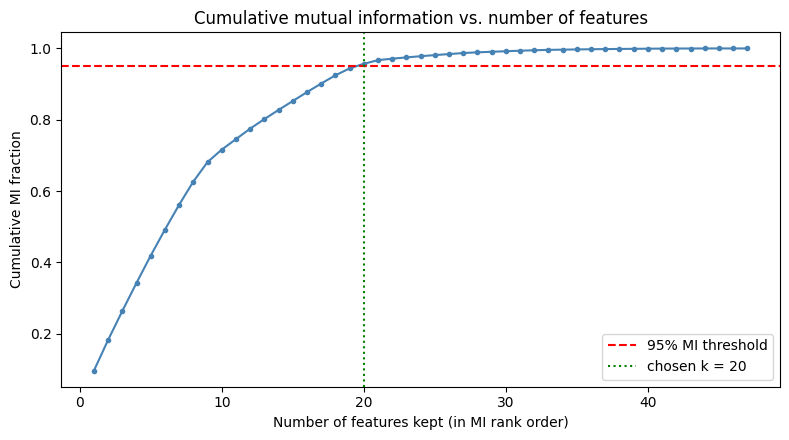

In [ ]:
# plot cumulative MI curve with the threshold and chosen K marked
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_mi) + 1), cum_mi.values, marker='.', color='steelblue')
plt.axhline(MI_THRESHOLD, color='red', linestyle='--', label=f'{MI_THRESHOLD:.0%} MI threshold')
plt.axvline(TOP_N, color='green', linestyle=':', label=f'chosen k = {TOP_N}')
plt.xlabel('Number of features kept (in MI rank order)')
plt.ylabel('Cumulative MI fraction')
plt.title('Cumulative mutual information vs. number of features')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# apply train-derived TOP_N selection to all three splits
selected_features = mi_series.head(TOP_N).index.tolist()

X_train_selected = X_train_numeric[selected_features]
X_val_selected = X_val_numeric[selected_features]
X_test_selected = X_test_numeric[selected_features]

print(f"Selected feature set ({TOP_N} features, derived from train MI ranking):")
for i, f in enumerate(selected_features, 1):
  print(f"{i:2d}. {f:35s} MI={mi_series[f]:.4f}")

Selected feature set (20 features, derived from train MI ranking):
 1. URLSimilarityIndex                  MI=0.6718
 2. LineOfCode                          MI=0.6009
 3. NoOfExternalRef                     MI=0.5647
 4. NoOfImage                           MI=0.5494
 5. NoOfSelfRef                         MI=0.5332
 6. NoOfJS                              MI=0.5069
 7. LargestLineLength                   MI=0.4858
 8. NoOfCSS                             MI=0.4526
 9. LetterRatioInURL                    MI=0.3808
10. NoOfOtherSpecialCharsInURL          MI=0.2426
11. DomainTitleMatchScore               MI=0.2050
12. SpacialCharRatioInURL               MI=0.2048
13. TLDLegitimateProb                   MI=0.1863
14. NoOfDegitsInURL                     MI=0.1788
15. NoOfEmptyRef                        MI=0.1742
16. NoOfiFrame                          MI=0.1736
17. URLLength                           MI=0.1679
18. CharContinuationRate                MI=0.1605
19. URLCharProb                  

# Feature Extraction (Creation)

In [ ]:
# domain-knowledge feature extraction from raw URL / Domain / Title strings

import re, math
from collections import Counter

# words common in credential-bait phishing URLs
SUSPICIOUS_KEYWORDS = ['login', 'signin', 'sign-in', 'verify', 'verification', 'secure', 'security',
                       'account', 'update', 'confirm', 'banking', 'webscr', 'admin', 'support',
                       'password', 'wallet', 'recover', 'auth', 'invoice', 'billing']

# popular brands that attackers may want to target bc they are somewhat high-value or well-known
BRAND_KEYWORDS = ['paypal', 'amazon', 'apple', 'microsoft', 'google', 'facebook',
                  'instagram', 'twitter', 'netflix', 'ebay', 'chase', 'wellsfargo',
                  'bankofamerica', 'citibank', 'hsbc', 'dropbox', 'linkedin']

# pre-compile regex patterns once (to avoid rebuilding them inside the per-row loop)
SUSP_RE = re.compile('|'.join(map(re.escape, SUSPICIOUS_KEYWORDS)))
BRAND_RE = re.compile('|'.join(map(re.escape, BRAND_KEYWORDS)))
IP_RE = re.compile(r'^\d{1,3}(?:\.\d{1,3}){3}') # bare IPv4 hostname
SCHEME_RE = re.compile(r'^https?://', re.IGNORECASE) # to strip http(s):// before parsing

# Shannon entropy of a string: random-looking domains have higher entropy than English-y ones
def shannon_entropy(s):
  if not s:
    return 0.0
  n = len(s)
  counts = Counter(s) # character frequencies
  return -sum((c / n) * math.log2(c / n) for c in counts.values())

# Pull engineered features out of a single (url, domain, title) row
def extract(url, domain, title):
  # cast to string in case anything is NaN / non-string
  url = url if isinstance(url, str)    else ''
  domain = domain if isinstance(domain, str) else ''
  title  = title if isinstance(title, str)  else ''
  u = url.lower() # lowercase once for keyword matching

  # split URL into host vs. path so we can analyze them separately
  no_scheme = SCHEME_RE.sub('', u) # drop the http(s):// prefix
  host_part, _, path_part = no_scheme.partition('/') # everything before / is the host
  host = host_part.split(':', 1)[0] # strip explicit :port for structural counts

  # character composition stats on the host
  n_letters = sum(c.isalpha() for c in host) # how many letters
  n_digits  = sum(c.isdigit() for c in host) # how many digits
  n_vowels  = sum(c in 'aeiou' for c in host) # how many vowels
  letters_safe = max(n_letters, 1) # prevent div-by-zero on weird hosts

  # brand-in-subdomain check (e.g. "paypal.com.evil.example")
  parts = host.split('.')
  has_brand_sub = 0
  if len(parts) >= 3: # only meaningful if there's a subdomain
    subdomain = '.'.join(parts[:-2]) # everything LEFT of the registrable domain
    if BRAND_RE.search(subdomain):
      has_brand_sub = 1

  return {
    # binary red-flags from the URL string itself
    'fe_has_ip': 1 if IP_RE.match(host_part) else 0, # bare IP instead of hostname
    'fe_has_at': 1 if '@' in u else 0, # @ trick to mask the real host
    'fe_has_double_slash_path': 1 if '//' in path_part else 0, # second // after the scheme
    'fe_has_punycode': 1 if 'xn--' in u else 0, # IDN -> homograph attack
    'fe_has_port': 1 if re.search(r':\d', host_part) else 0, # explicit non-standard port
    # structural counts on the host
    'fe_num_hyphens_host': host.count('-'), # phishing hosts skew hyphen-heavy
    'fe_num_dots_host': host.count('.'), # subdomain depth
    # keyword detection
    'fe_n_suspicious_kw': len(SUSP_RE.findall(u)), # how many bait words appear
    'fe_has_brand_kw_in_subdomain': has_brand_sub, # spoofed brand left of root
    # entropy / randomness
    'fe_url_entropy': shannon_entropy(u),
    'fe_host_entropy': shannon_entropy(host),
    # composition ratios
    'fe_digit_letter_ratio_host': n_digits / letters_safe,
    'fe_vowel_ratio_host': n_vowels / letters_safe,
    # path / query structure
    'fe_path_length': len(path_part),
    'fe_num_path_segments': path_part.count('/'),
    'fe_has_query': 1 if '?' in u else 0,
    'fe_has_fragment': 1 if '#' in u else 0,
    # title features
    'fe_title_length': len(title),
    'fe_title_word_count': len(title.split()),
    'fe_title_empty': 1 if len(title.strip()) == 0 else 0,
    'fe_title_has_brand': 1 if BRAND_RE.search(title.lower()) else 0,
  }

In [ ]:
section_start("feature_extraction")

# apply extractor per split
def make_engineered(X_split):
  return pd.DataFrame.from_records(
    [extract(u, d, t) for u, d, t in zip(X_split['URL'], X_split['Domain'], X_split['Title'])],
    index=X_split.index,
  )

eng_train = make_engineered(X_train)
eng_val = make_engineered(X_val)
eng_test = make_engineered(X_test)

print(f"Engineered {eng_train.shape[1]} new features per split")
print(f"train: {eng_train.shape}")
print(f"val: {eng_val.shape}")
print(f"test: {eng_test.shape}")
eng_train.head()

[START] feature_extraction
Engineered 21 new features per split
train: (164992, 21)
val: (35356, 21)
test: (35356, 21)


,fe_has_ip,fe_has_at,fe_has_double_slash_path,fe_has_punycode,fe_has_port,fe_num_hyphens_host,fe_num_dots_host,fe_n_suspicious_kw,fe_has_brand_kw_in_subdomain,fe_url_entropy,...,fe_digit_letter_ratio_host,fe_vowel_ratio_host,fe_path_length,fe_num_path_segments,fe_has_query,fe_has_fragment,fe_title_length,fe_title_word_count,fe_title_empty,fe_title_has_brand
0,0,0,0,0,0,0,2,0,0,3.783465,...,0.0,0.333333,0,0,0,0,9,1,0,0
1,0,0,0,0,0,1,2,0,0,4.039149,...,0.0,0.235294,0,0,0,0,12,1,0,0
2,0,0,0,0,0,0,2,0,0,3.969002,...,0.0,0.307692,0,0,0,0,8,1,0,0
3,0,0,0,0,0,0,2,0,0,3.646439,...,0.0,0.181818,0,0,0,0,5,1,0,0
4,0,0,0,0,0,0,3,0,0,3.964735,...,0.0,0.368421,0,0,0,0,13,1,0,0


In [ ]:
# fe_url_title_max_sq: square of whichever is longer - the URL or the page title
# phishing pages often have very long obfuscated URLs paired with very short/empty titles,
# or copy legitimate long titles while using short redirect URLs.
# squaring amplifies the signal from extreme lengths.
for split_eng, split_X in [(eng_train, X_train), (eng_val, X_val), (eng_test, X_test)]:
    split_eng['fe_url_title_max_sq'] = split_X['URL'].str.len().fillna(0).combine(
        split_X['Title'].str.len().fillna(0), max
    ) ** 2

print(f"Added fe_url_title_max_sq — eng_train shape: {eng_train.shape}")
print(f"Sample stats:\n{eng_train['fe_url_title_max_sq'].describe().round(1)}")

Added fe_url_title_max_sq — eng_train shape: (164992, 22)
Sample stats:
count      164992.0
mean         3152.0
std        152584.7
min           196.0
25%           576.0
50%           784.0
75%          1225.0
max      37173409.0
Name: fe_url_title_max_sq, dtype: float64


In [ ]:
list(eng_train.columns)

['fe_has_ip',
 'fe_has_at',
 'fe_has_double_slash_path',
 'fe_has_punycode',
 'fe_has_port',
 'fe_num_hyphens_host',
 'fe_num_dots_host',
 'fe_n_suspicious_kw',
 'fe_has_brand_kw_in_subdomain',
 'fe_url_entropy',
 'fe_host_entropy',
 'fe_digit_letter_ratio_host',
 'fe_vowel_ratio_host',
 'fe_path_length',
 'fe_num_path_segments',
 'fe_has_query',
 'fe_has_fragment',
 'fe_title_length',
 'fe_title_word_count',
 'fe_title_empty',
 'fe_title_has_brand',
 'fe_url_title_max_sq']

In [ ]:
# sanity-check on TRAIN: are the engineered features actually informative?
# we calculate the class-mean gap and DROP features whose gap is essentially zero

GAP_THRESHOLD = 0.001 # |phish_mean - legit_mean| must exceed this

summary = eng_train.copy()
summary["is_phish"] = y_train
by_class = summary.groupby("is_phish").mean().T
by_class.columns = ["legit", "phish"]
by_class["gap"] = (by_class["phish"] - by_class["legit"])

# sort so the most discriminative features are at top
print("Engineered features ranked by class-mean gap (train):")
print(by_class.round(4).sort_values("gap", key=lambda s: s.abs(), ascending=False))

# drop features below the gap threshold bc they don't actually separate phishing from legit
uninformative = by_class[by_class["gap"].abs() < GAP_THRESHOLD].index.tolist()
print()
print(f"Dropping {len(uninformative)} engineered feature(s) with |gap| < {GAP_THRESHOLD}:")
for f in uninformative:
  print(f"{f}: gap = {by_class.loc[f, 'gap']:.6f}")

eng_train = eng_train.drop(columns=uninformative)
eng_val = eng_val.drop(columns=uninformative)
eng_test = eng_test.drop(columns=uninformative)
print()
print(f"Kept {eng_train.shape[1]} engineered features")

Engineered features ranked by class-mean gap (train):
                                 legit      phish        gap
fe_url_title_max_sq           767.8597  6339.8456  5571.9859
fe_path_length                  0.0000    13.8009    13.8009
fe_title_length                11.0740    22.4837    11.4097
fe_num_hyphens_host             0.0831     0.5482     0.4651
fe_num_path_segments            0.0000     0.4194     0.4194
fe_url_entropy                  3.8532     4.1048     0.2517
fe_host_entropy                 3.3762     3.6001     0.2238
fe_digit_letter_ratio_host      0.0044     0.1773     0.1729
fe_n_suspicious_kw              0.0036     0.1353     0.1318
fe_has_query                    0.0000     0.0610     0.0610
fe_vowel_ratio_host             0.2991     0.3218     0.0228
fe_title_has_brand              0.0012     0.0229     0.0217
fe_has_at                       0.0000     0.0150     0.0150
fe_has_fragment                 0.0000     0.0085     0.0085
fe_has_brand_kw_in_subdomain   

In [ ]:
# apply same transformation pipeline to engineered features as we did to the original
# numeric features: Yeo-Johnson/Box-Cox when |skew| > 1, then z-score. Fit on TRAIN only
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import StandardScaler

eng_fitted = {} # col -> (method, lambda, mean, std)

for col in eng_train.columns:
  train_vals = eng_train[col].values
  skew_val   = eng_train[col].skew()

  if abs(skew_val) > 1:
    # heavily skewed -- apply power transform first
    if (train_vals <= 0).any():
      tr_train, lam = yeojohnson(train_vals) # handles zeros / negatives
      method = "yeojohnson"
      tr_val = yeojohnson(eng_val[col].values,  lmbda=lam)
      tr_test = yeojohnson(eng_test[col].values, lmbda=lam)
    else:
      tr_train, lam = boxcox(train_vals) # strictly positive
      method = "boxcox"
      tr_val = boxcox(eng_val[col].values,  lmbda=lam)
      tr_test = boxcox(eng_test[col].values, lmbda=lam)
  else:
    # mild skew --> pass through, just z-score below
    method, lam = "identity", None
    tr_train, tr_val, tr_test = train_vals, eng_val[col].values, eng_test[col].values

  # z-score using TRAIN mean/std
  train_mean = tr_train.mean()
  train_std = tr_train.std() if tr_train.std() > 0 else 1.0
  eng_fitted[col] = (method, lam, train_mean, train_std)

  eng_train[col] = (tr_train - train_mean) / train_std
  eng_val[col] = (tr_val   - train_mean) / train_std
  eng_test[col] = (tr_test  - train_mean) / train_std

# show what got transformed vs. passed through
import collections
methods_used = collections.Counter(v[0] for v in eng_fitted.values())
print("Engineered feature transformation methods:", dict(methods_used))
print()
print("Engineered features after transformation (sample of 5):")
print(eng_train.agg(["mean", "std"]).round(3).T.head())

Engineered feature transformation methods: {'yeojohnson': 13, 'boxcox': 3, 'identity': 3}

Engineered features after transformation (sample of 5):
                          mean  std
fe_has_ip                  0.0  1.0
fe_has_at                 -0.0  1.0
fe_has_double_slash_path   0.0  1.0
fe_has_punycode            0.0  1.0
fe_num_hyphens_host       -0.0  1.0


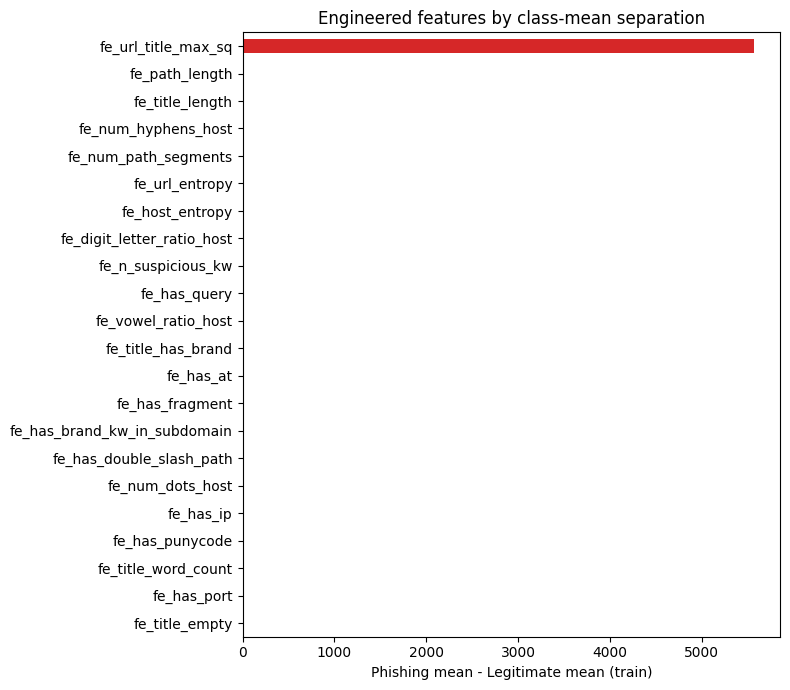

[END]   feature_extraction — 17.1s


In [ ]:
# bar chart of class-mean gaps
gap_sorted = by_class.sort_values('gap', key=lambda s: s.abs(), ascending=True)['gap']

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in gap_sorted.values] # red = phish-leaning
gap_sorted.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Phishing mean - Legitimate mean (train)')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('Engineered features by class-mean separation')
plt.tight_layout()
plt.show()

section_end("feature_extraction")

In [ ]:
section_start("feature_selection")

# add engineered features onto the selected-feature set, per split.
# drop URL/Domain/Title text columns now that we've extracted features from them.
def assemble(X_sel, eng):
  out = pd.concat([X_sel.reset_index(drop=True), eng.reset_index(drop=True)], axis=1)
  text_cols = [c for c in ['URL', 'Domain', 'Title'] if c in out.columns]
  if text_cols:
    out = out.drop(columns=text_cols)
  return out

X_train_final = assemble(X_train_selected, eng_train)
X_val_final = assemble(X_val_selected,   eng_val)
X_test_final = assemble(X_test_selected,  eng_test)

print(f"Final feature matrix shapes:")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")
print(f"({len(selected_features)} selected + {eng_train.shape[1]} engineered)")

section_end("feature_selection")

[START] feature_selection
Final feature matrix shapes:
X_train_final: (164992, 39)
X_val_final:   (35356, 39)
X_test_final:  (35356, 39)
(20 selected + 19 engineered)
[END]   feature_selection — 0.1s


PCA fit on train: 39 -> 24 components (95% variance retained)


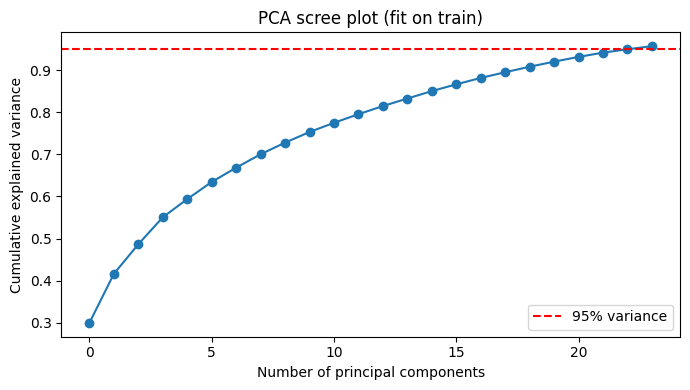

In [ ]:
# PCA fit on TRAIN only, then applied to val and test
# no need to scale again because we already scaled above

from sklearn.decomposition import PCA

# fit PCA on train, transform all splits
pca = PCA(n_components=0.95, random_state=42).fit(X_train_final.fillna(0))
X_train_pca = pca.transform(X_train_final.fillna(0))
X_val_pca = pca.transform(X_val_final.fillna(0))
X_test_pca = pca.transform(X_test_final.fillna(0))

print(f"PCA fit on train: {X_train_final.shape[1]} -> {X_train_pca.shape[1]} components (95% variance retained)")

# scree-style plot from train
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA scree plot (fit on train)")
plt.legend()
plt.tight_layout()
plt.show()

# Modeling

In [ ]:
# rebuild MI ranking without URLSimilarityIndex so we can compare with vs without it
# (URLSimilarityIndex is somewhat leaky bc it's built from a curated allow-list)
EXCLUDE = ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']

mi_no_usi = mi_series[~mi_series.index.isin(EXCLUDE)]

drop_train = [c for c in EXCLUDE if c in X_train_numeric.columns]
drop_val   = [c for c in EXCLUDE if c in X_val_numeric.columns]
drop_test  = [c for c in EXCLUDE if c in X_test_numeric.columns]

X_train_numeric_no_usi = X_train_numeric.drop(columns=drop_train)
X_val_numeric_no_usi   = X_val_numeric.drop(columns=drop_val)
X_test_numeric_no_usi  = X_test_numeric.drop(columns=drop_test)

# same cumulative MI threshold, just on the no-USI ranking
cum_mi_no_usi = mi_no_usi.cumsum() / mi_no_usi.sum()
mask_no_usi = cum_mi_no_usi.values >= MI_THRESHOLD
TOP_N_NO_USI = int(np.argmax(mask_no_usi) + 1) if mask_no_usi.any() else len(cum_mi_no_usi)

print(f"With USI --> TOP_N = {TOP_N}  (cum MI = {cum_mi.iloc[TOP_N-1]:.3f})")
print(f"Without USI --> TOP_N = {TOP_N_NO_USI}  (cum MI = {cum_mi_no_usi.iloc[TOP_N_NO_USI-1]:.3f})")

selected_no_usi = mi_no_usi.head(TOP_N_NO_USI).index.tolist()

With USI --> TOP_N = 20  (cum MI = 0.957)
Without USI --> TOP_N = 18  (cum MI = 0.962)


In [ ]:
# build the 4 feature representations: with/without USI, each with/without PCA

# with-USI base = already built earlier
fs_with_usi = (X_train_final, X_val_final, X_test_final)

# without-USI base = top-K no-USI MI features + engineered features
fs_without_usi = (
  pd.concat([X_train_numeric_no_usi[selected_no_usi].reset_index(drop=True), eng_train.reset_index(drop=True)], axis=1),
  pd.concat([X_val_numeric_no_usi[selected_no_usi].reset_index(drop=True), eng_val.reset_index(drop=True)], axis=1),
  pd.concat([X_test_numeric_no_usi[selected_no_usi].reset_index(drop=True), eng_test.reset_index(drop=True)], axis=1),
)

# refit PCA on each base set's train portion (no leakage)
def pca_reduce_split(X_train, X_val, X_test, name):
  p = PCA(n_components=0.95, random_state=42).fit(X_train.fillna(0))
  print(f"{name}: {X_train.shape[1]} -> {p.n_components_} components")
  return (p.transform(X_train.fillna(0)), p.transform(X_val.fillna(0)), p.transform(X_test.fillna(0)))

print("PCA reduction (95% variance, fit on train):")
fs_with_usi_pca = pca_reduce_split(*fs_with_usi, 'with USI')
fs_without_usi_pca = pca_reduce_split(*fs_without_usi, 'without USI')

# package the four representations
feature_sets = {
  'with_usi': fs_with_usi,
  'with_usi_pca': fs_with_usi_pca,
  'without_usi': fs_without_usi,
  'without_usi_pca': fs_without_usi_pca,
}

print(f"\nFinal feature-set shapes (train rows x cols):")
for name, (X_tr, X_va, X_te) in feature_sets.items():
  print(f"{name}: train={X_tr.shape[0]} x {X_tr.shape[1]}")


PCA reduction (95% variance, fit on train):
with USI: 39 -> 24 components
without USI: 37 -> 22 components

Final feature-set shapes (train rows x cols):
with_usi: train=164992 x 39
with_usi_pca: train=164992 x 24
without_usi: train=164992 x 37
without_usi_pca: train=164992 x 22


### Define the Classifiers

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow import keras

In [ ]:
# RBF SVM wrapper that subsamples training data for tractability
# (kernel SVM is very slow so we sample to ~20K instead)
# set n_train=None to get rid of subsampling and train on all rows (btw this will be extremely slow!!)
class RBFSVMWrapper:
  def __init__(self, C=1.0, gamma='scale', n_train=20000, random_state=42):
    self.C, self.gamma, self.n_train, self.random_state = C, gamma, n_train, random_state
  def fit(self, X, y):
    if self.n_train and X.shape[0] > self.n_train:
      rng = np.random.default_rng(self.random_state)
      idx = rng.choice(X.shape[0], size=self.n_train, replace=False)
      X, y = X[idx], y[idx]
    self.model = SVC(C=self.C, kernel='rbf', gamma=self.gamma, random_state=self.random_state)
    self.model.fit(X, y)
    return self
  def predict(self, X):
    return self.model.predict(X)
  def decision_function(self, X):
    return self.model.decision_function(X)

In [ ]:
# Keras MLP with dropout (sklearn's MLPClassifier doesn't support dropout)
# architecture: 128 --> dropout --> 64 --> dropout --> 32 --> sigmoid (binary classification)
# uses outer val set for early stopping (passed in via X_val/y_val)
class KerasMLP:
  def __init__(self, dropout=0.2, epochs=20, batch_size=256, random_state=42):
    self.dropout, self.epochs, self.batch_size, self.random_state = dropout, epochs, batch_size, random_state
  def fit(self, X, y, X_val=None, y_val=None):
    tf.random.set_seed(self.random_state)
    self.model = keras.Sequential([
      keras.layers.Input(shape=(X.shape[1],)),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dropout(self.dropout),
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dropout(self.dropout),
      keras.layers.Dense(32, activation='relu'),
      keras.layers.Dense(1, activation='sigmoid'), # output layer for binary classification
    ])
    self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    # use outer val if provided, otherwise fall back to internal split
    if X_val is not None:
      self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    else:
      self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, validation_split=0.1, callbacks=[es], verbose=0)
    return self
  def predict(self, X):
    return (self.model.predict(X, verbose=0).ravel() > 0.5).astype(int)
  def predict_proba(self, X):
    p = self.model.predict(X, verbose=0).ravel()
    return np.column_stack([1 - p, p])

In [ ]:
# KNN that picks k=3..10 using performance on the outer val set
class KNNTuned:
  def __init__(self, k_range=range(3, 11)):
    self.k_range = k_range
  def fit(self, X, y, X_val=None, y_val=None):
    best_score, best_k, best_model = -1, None, None
    for k in self.k_range:
      m = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
      m.fit(X, y)
      score = f1_score(y_val, m.predict(X_val)) # tune on val F1
      if score > best_score:
        best_score, best_k, best_model = score, k, m
    self.model, self.best_k = best_model, best_k
    print(f"KNN --> best k = {best_k} (val F1 = {best_score:.4f})")
    return self
  def predict(self, X):
    return self.model.predict(X)
  def predict_proba(self, X):
    return self.model.predict_proba(X)

In [ ]:
# Random Forest that picks n_estimators from [50, 100, 150, 200] using val performance
class RFTuned:
  def __init__(self, n_estimators_range=(50, 100, 150, 200), random_state=42):
    self.n_estimators_range, self.random_state = n_estimators_range, random_state
  def fit(self, X, y, X_val=None, y_val=None):
    best_score, best_n, best_model = -1, None, None
    for n in self.n_estimators_range:
      m = RandomForestClassifier(n_estimators=n, max_depth=None, min_samples_leaf=2, n_jobs=-1, random_state=self.random_state)
      m.fit(X, y)
      score = f1_score(y_val, m.predict(X_val))
      if score > best_score:
        best_score, best_n, best_model = score, n, m
    self.model, self.best_n = best_model, best_n
    print(f"RF --> best n_estimators = {best_n} (val F1 = {best_score:.4f})")
    return self
  def predict(self, X):
    return self.model.predict(X)
  def predict_proba(self, X):
    return self.model.predict_proba(X)

In [ ]:
def make_models():
  return {
    # logistic regression: simple linear baseline
    'LogReg': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, n_jobs=-1, random_state=42),
    # RBF SVM: subsamples to ~20K rows bc kernel SVM is O(n^2) on training size
    'RBFSVM': RBFSVMWrapper(C=1.0, gamma='scale', n_train=20000, random_state=42),
    # KNN: k chosen via val F1 over k=3..10
    'KNN': KNNTuned(k_range=range(3, 11)),
    # MLP: 128 --> 64 --> 32 with dropout between hidden layers, sigmoid output for binary classification
    'MLP': KerasMLP(dropout=0.2, epochs=20, batch_size=256, random_state=42),
    # random forest: n_estimators chosen via val F1 over [50, 100, 150, 200]
    'RandomForest': RFTuned(n_estimators_range=(50, 100, 150, 200), random_state=42),
    # histogram gradient boosting
    'HistGB': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, max_leaf_nodes=63, early_stopping=True, validation_fraction=0.1, random_state=42),
  }

In [ ]:
section_start("modeling")

# train all 6 models on each of the 4 feature representations (24 fits total)
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# tree-based models are scale-invariant, the others need standardized input
SCALE_DEPENDENT = {'LogReg', 'RBFSVM', 'KNN', 'MLP'}
# tunable models take (X_val, y_val) in fit() and use them for internal hyperparam search
TUNABLE = {'KNN', 'RandomForest', 'MLP'}

results = []
trained_models = {}
trained_scalers = {}

for fs_name, (X_tr_fs, X_va_fs, X_te_fs) in feature_sets.items():
  # convert DataFrames to arrays where needed (PCA outputs are already arrays)
  X_tr = X_tr_fs.values if hasattr(X_tr_fs, 'values') else X_tr_fs
  X_va = X_va_fs.values if hasattr(X_va_fs, 'values') else X_va_fs
  X_te = X_te_fs.values if hasattr(X_te_fs, 'values') else X_te_fs

  # fit scaler on train only (no leakage from val/test)
  # this is needed for PCA components since they have eigenvalue variance, not unit variance
  scaler = StandardScaler().fit(X_tr)
  X_tr_s, X_va_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_va), scaler.transform(X_te)
  trained_scalers[fs_name] = scaler

  print(f"\n{fs_name} (n_features={X_tr.shape[1]})")
  for m_name, model in make_models().items():
    t0 = time.time()
    # scale-dependent models get standardized inputs; trees get raw
    if m_name in SCALE_DEPENDENT:
      Xt, Xv, Xs = X_tr_s, X_va_s, X_te_s
    else:
      Xt, Xv, Xs = X_tr, X_va, X_te

    # tunable models also get val data so they can do internal hyperparam search
    if m_name in TUNABLE:
      model.fit(Xt, y_train, X_val=Xv, y_val=y_val)
    else:
      model.fit(Xt, y_train)
    elapsed = time.time() - t0

    # test predictions and decision scores (for AUC)
    y_pred = model.predict(Xs)
    if hasattr(model, 'predict_proba'):
      y_score = model.predict_proba(Xs)[:, 1]
    elif hasattr(model, 'decision_function'):
      y_score = model.decision_function(Xs)
    else:
      y_score = y_pred

    results.append({
      'feature_set': fs_name,
      'model': m_name,
      'accuracy': accuracy_score(y_test, y_pred),
      'precision': precision_score(y_test, y_pred),
      'recall': recall_score(y_test, y_pred),
      'f1': f1_score(y_test, y_pred),
      'roc_auc': roc_auc_score(y_test, y_score),
      'fit_time_s': elapsed,
      'n_features': X_tr.shape[1],
    })
    trained_models[(fs_name, m_name)] = model
    r = results[-1]
    print(f"-->{m_name}: acc={r['accuracy']:.4f} f1={r['f1']:.4f} auc={r['roc_auc']:.4f} ({elapsed:.1f}s)")

results_df = pd.DataFrame(results)
print(f"\nDone --> {len(results)} model fits total")
section_end("modeling")

[START] modeling

with_usi (n_features=39)
-->LogReg: acc=0.9998 f1=0.9998 auc=1.0000 (3.1s)
-->RBFSVM: acc=0.9995 f1=0.9994 auc=1.0000 (0.7s)
KNN --> best k = 4 (val F1 = 0.9984)
-->KNN: acc=0.9986 f1=0.9983 auc=0.9994 (359.0s)
-->MLP: acc=0.9999 f1=0.9999 auc=1.0000 (50.5s)
RF --> best n_estimators = 50 (val F1 = 0.9999)
-->RandomForest: acc=1.0000 f1=1.0000 auc=1.0000 (99.9s)
-->HistGB: acc=0.9999 f1=0.9999 auc=1.0000 (7.3s)

with_usi_pca (n_features=24)
-->LogReg: acc=0.9984 f1=0.9981 auc=1.0000 (2.7s)
-->RBFSVM: acc=0.9977 f1=0.9974 auc=1.0000 (0.9s)
KNN --> best k = 8 (val F1 = 0.9965)
-->KNN: acc=0.9977 f1=0.9973 auc=0.9993 (305.8s)
-->MLP: acc=0.9987 f1=0.9985 auc=1.0000 (61.7s)
RF --> best n_estimators = 200 (val F1 = 0.9976)
-->RandomForest: acc=0.9979 f1=0.9976 auc=0.9999 (676.2s)
-->HistGB: acc=0.9985 f1=0.9982 auc=1.0000 (5.1s)

without_usi (n_features=37)
-->LogReg: acc=0.9988 f1=0.9986 auc=1.0000 (3.0s)
-->RBFSVM: acc=0.9986 f1=0.9984 auc=1.0000 (0.7s)
KNN --> best k = 6

In [ ]:
# pivot views: rows = model, cols = feature representation
pivot_f1        = results_df.pivot(index='model', columns='feature_set', values='f1').round(4)
pivot_acc       = results_df.pivot(index='model', columns='feature_set', values='accuracy').round(4)
pivot_auc       = results_df.pivot(index='model', columns='feature_set', values='roc_auc').round(4)
pivot_precision = results_df.pivot(index='model', columns='feature_set', values='precision').round(4)
pivot_recall    = results_df.pivot(index='model', columns='feature_set', values='recall').round(4)

# reorder columns so with-USI and without-USI sit side by side
col_order = ['with_usi', 'with_usi_pca', 'without_usi', 'without_usi_pca']
pivot_f1        = pivot_f1[col_order]
pivot_acc       = pivot_acc[col_order]
pivot_auc       = pivot_auc[col_order]
pivot_precision = pivot_precision[col_order]
pivot_recall    = pivot_recall[col_order]

print("Test F1")
print(pivot_f1)
print()
print("Test accuracy")
print(pivot_acc)
print()
print("Test ROC AUC")
print(pivot_auc)
print()
print("Test Precision")
print(pivot_precision)
print()
print("Test Recall")
print(pivot_recall)

Test F1
feature_set   with_usi  with_usi_pca  without_usi  without_usi_pca
model                                                             
HistGB          0.9999        0.9982       0.9992           0.9981
KNN             0.9983        0.9973       0.9978           0.9967
LogReg          0.9998        0.9981       0.9986           0.9964
MLP             0.9999        0.9985       0.9996           0.9981
RBFSVM          0.9994        0.9974       0.9984           0.9964
RandomForest    1.0000        0.9976       0.9983           0.9972

Test accuracy
feature_set   with_usi  with_usi_pca  without_usi  without_usi_pca
model                                                             
HistGB          0.9999        0.9985       0.9993           0.9984
KNN             0.9986        0.9977       0.9981           0.9972
LogReg          0.9998        0.9984       0.9988           0.9969
MLP             0.9999        0.9987       0.9997           0.9984
RBFSVM          0.9995        0.9977   

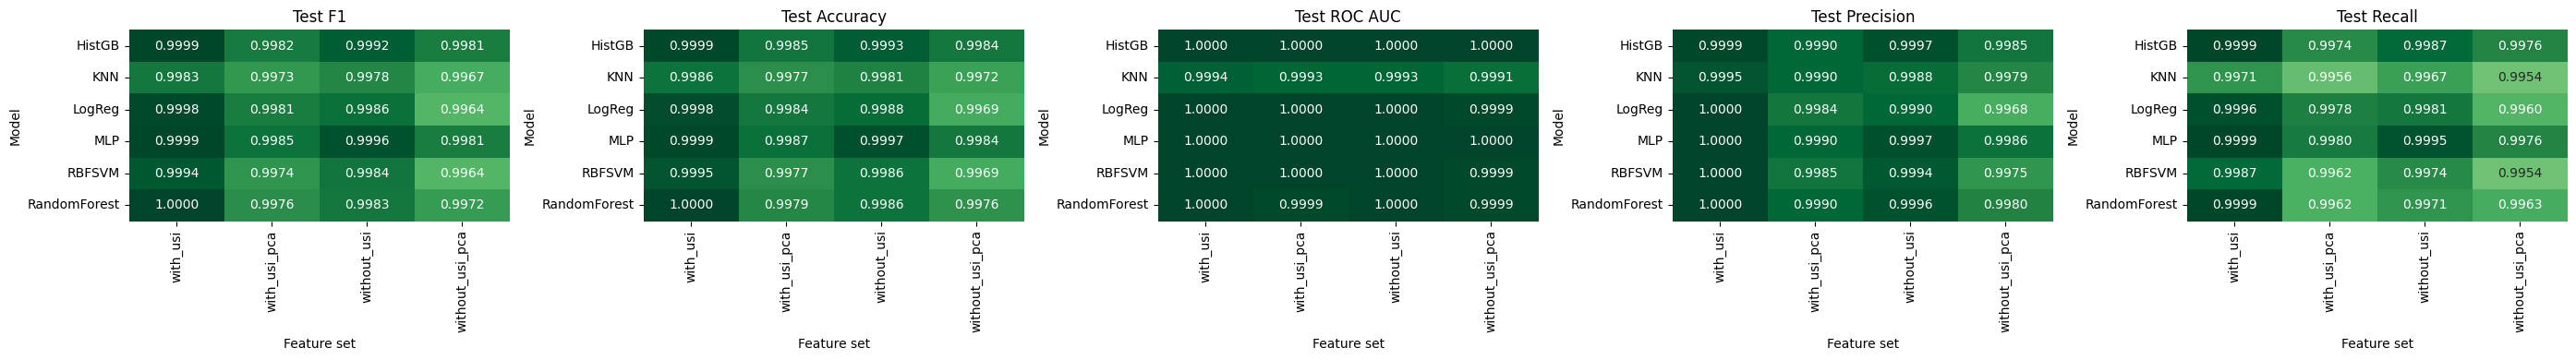

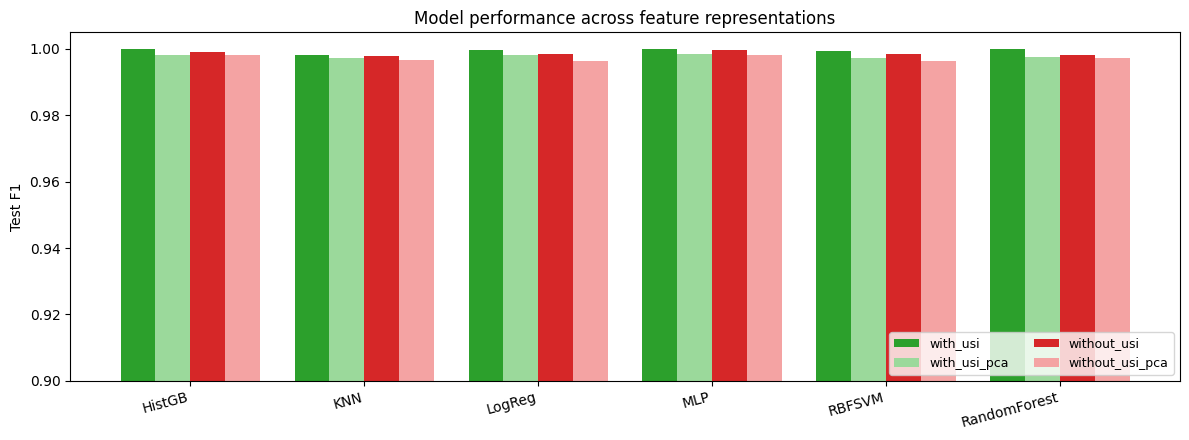

In [ ]:
# heatmap of all 5 metrics across the 6 x 4 grid
fig, axes = plt.subplots(1, 5, figsize=(28, 4))
for ax, (metric, pv) in zip(axes, [('F1', pivot_f1), ('Accuracy', pivot_acc), ('ROC AUC', pivot_auc),
                                    ('Precision', pivot_precision), ('Recall', pivot_recall)]):
  sns.heatmap(pv, annot=True, fmt='.4f', cmap='YlGn', vmin=max(pv.values.min() - 0.005, 0.0), vmax=1.0, ax=ax, cbar=False)
  ax.set_title(f'Test {metric}')
  ax.set_xlabel('Feature set')
  ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

# grouped bar chart — unchanged
fig, ax = plt.subplots(figsize=(12, 4.5))
colors = {'with_usi': '#2ca02c', 'with_usi_pca': '#9bd99b',
          'without_usi': '#d62728', 'without_usi_pca': '#f4a3a3'}
n_models = len(pivot_f1.index)
width = 0.20
x = np.arange(n_models)
for i, fs in enumerate(col_order):
  ax.bar(x + (i - 1.5) * width, pivot_f1[fs].values, width, label=fs, color=colors[fs])
ax.set_xticks(x)
ax.set_xticklabels(pivot_f1.index, rotation=15, ha='right')
ax.set_ylabel('Test F1')
ax.set_title('Model performance across feature representations')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.set_ylim(min(pivot_f1.values.min() - 0.02, 0.9), 1.005)
plt.tight_layout()
plt.show()

In [ ]:
# rank models on the realistic feature set (without USI, no PCA)
# this is the closest to deployment since USI requires a curated allow-list lookup that we wouldn't have for unseen URLs
realistic = results_df[results_df['feature_set'] == 'without_usi'].sort_values('f1', ascending=False)
print("Ranking on realistic feature set (without USI, no PCA):")
print(realistic[['model', 'f1', 'accuracy', 'recall', 'precision', 'roc_auc', 'fit_time_s']].round(4).to_string(index=False))

Ranking on realistic feature set (without USI, no PCA):
       model     f1  accuracy  recall  precision  roc_auc  fit_time_s
         MLP 0.9996    0.9997  0.9995     0.9997   1.0000     43.1048
      HistGB 0.9992    0.9993  0.9987     0.9997   1.0000      9.5016
      LogReg 0.9986    0.9988  0.9981     0.9990   1.0000      2.9761
      RBFSVM 0.9984    0.9986  0.9974     0.9994   1.0000      0.7010
RandomForest 0.9983    0.9986  0.9971     0.9996   1.0000    162.4929
         KNN 0.9978    0.9981  0.9967     0.9988   0.9993    343.1338


In [ ]:
# pick best model from realistic feature set and save for deployment
import joblib

realistic_results = results_df[results_df['feature_set'] == 'without_usi']
best_row = realistic_results.sort_values('f1', ascending=False).iloc[0]
best_fs = best_row['feature_set']
best_mname = best_row['model']
best_model = trained_models[(best_fs, best_mname)]
best_scaler = trained_scalers[best_fs]

print(f"Deploying: {best_mname} on '{best_fs}'")
print(f"test F1 = {best_row['f1']:.4f}, recall = {best_row['recall']:.4f}, AUC = {best_row['roc_auc']:.4f}")

# bundle (model + scaler + column list) so a downstream service can score new URLs
fs_train = feature_sets[best_fs][0]
artifact = {
  'model': best_model,
  'scaler': best_scaler,
  'feature_columns': list(fs_train.columns) if hasattr(fs_train, 'columns') else None,
  'scale_dependent': best_mname in SCALE_DEPENDENT,
  'positive_class': 1, # 1 = phishing
}

out_path = 'phishing_classifier_best.joblib'
joblib.dump(artifact, out_path)

# sanity check
loaded = joblib.load(out_path)
fs_test = feature_sets[best_fs][2]
X_te_arr = (fs_test.values if hasattr(fs_test, 'values') else fs_test)[:20]
if loaded['scale_dependent']:
  X_te_arr = loaded['scaler'].transform(X_te_arr)
preds = loaded['model'].predict(X_te_arr)
print(f"\nSanity check on first 20 test rows:")
print(f"predicted: {preds.tolist()}")
print(f"actual   : {y_test[:20].tolist()}")

Deploying: MLP on 'without_usi'
test F1 = 0.9996, recall = 0.9995, AUC = 1.0000

Sanity check on first 20 test rows:
predicted: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]
actual   : [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]


# Evaluation Protocol, Comparison, Ablation, Selection, Errors

everything below is run on the realistic feature set (without_usi, no pca) since that is what we ship.
the test set is touched only here for final evaluation. no model training, no hyperparameter pick, and no
feature pick uses the test set.


In [ ]:
# multi-seed run on without_usi feature set so we can report mean +/- std across seeds.
# also adds cohen's kappa and pr auc on top of the existing metric set.
from sklearn.metrics import cohen_kappa_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

SEEDS = [42, 7, 123]
EVAL_FS = 'without_usi'

def make_models_seeded(seed):
  return {
    'LogReg': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, n_jobs=-1, random_state=seed),
    'RBFSVM': RBFSVMWrapper(C=1.0, gamma='scale', n_train=20000, random_state=seed),
    'KNN': KNNTuned(k_range=range(3, 11)),
    'MLP': KerasMLP(dropout=0.2, epochs=20, batch_size=256, random_state=seed),
    'RandomForest': RFTuned(n_estimators_range=(50, 100, 150, 200), random_state=seed),
    'HistGB': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, max_leaf_nodes=63, early_stopping=True, validation_fraction=0.1, random_state=seed),
  }

X_tr_fs, X_va_fs, X_te_fs = feature_sets[EVAL_FS]
X_tr = X_tr_fs.values if hasattr(X_tr_fs, 'values') else X_tr_fs
X_va = X_va_fs.values if hasattr(X_va_fs, 'values') else X_va_fs
X_te = X_te_fs.values if hasattr(X_te_fs, 'values') else X_te_fs

scaler_eval = StandardScaler().fit(X_tr)
X_tr_s = scaler_eval.transform(X_tr)
X_va_s = scaler_eval.transform(X_va)
X_te_s = scaler_eval.transform(X_te)

multi_seed_rows = []
seeded_models = {}
seeded_preds = {}

for seed in SEEDS:
  print(f"seed {seed}")
  for m_name, model in make_models_seeded(seed).items():
    if m_name in SCALE_DEPENDENT:
      Xt, Xv, Xs, Xtrn = X_tr_s, X_va_s, X_te_s, X_tr_s
    else:
      Xt, Xv, Xs, Xtrn = X_tr, X_va, X_te, X_tr

    t0 = time.time()
    if m_name in TUNABLE:
      model.fit(Xt, y_train, X_val=Xv, y_val=y_val)
    else:
      model.fit(Xt, y_train)
    fit_time = time.time() - t0

    # inference time per sample averaged across the test set
    t1 = time.time()
    y_pred = model.predict(Xs)
    inf_total = time.time() - t1
    inf_ms = (inf_total / len(Xs)) * 1000.0

    if hasattr(model, 'predict_proba'):
      y_score = model.predict_proba(Xs)[:, 1]
    elif hasattr(model, 'decision_function'):
      y_score = model.decision_function(Xs)
    else:
      y_score = y_pred

    y_pred_train = model.predict(Xtrn)

    multi_seed_rows.append({
      'model': m_name,
      'seed': seed,
      'accuracy':  accuracy_score(y_test, y_pred),
      'precision': precision_score(y_test, y_pred),
      'recall':    recall_score(y_test, y_pred),
      'f1':        f1_score(y_test, y_pred),
      'roc_auc':   roc_auc_score(y_test, y_score),
      'pr_auc':    average_precision_score(y_test, y_score),
      'cohen_kappa': cohen_kappa_score(y_test, y_pred),
      'train_acc': accuracy_score(y_train, y_pred_train),
      'fit_time_s': fit_time,
      'inf_ms_per_sample': inf_ms,
    })
    seeded_models[(m_name, seed)] = model
    seeded_preds[(m_name, seed)] = y_pred
    r = multi_seed_rows[-1]
    print(f"  {m_name:13s} f1={r['f1']:.4f}  kappa={r['cohen_kappa']:.4f}  fit={fit_time:5.1f}s  inf={inf_ms:.4f}ms")

multi_seed_df = pd.DataFrame(multi_seed_rows)
print(f"\ntotal fits: {len(multi_seed_df)}  ({len(SEEDS)} seeds x {len(multi_seed_df['model'].unique())} models)")

seed 42
  LogReg        f1=0.9986  kappa=0.9975  fit=  3.2s  inf=0.0001ms
  RBFSVM        f1=0.9984  kappa=0.9972  fit=  0.7s  inf=0.0331ms
KNN --> best k = 6 (val F1 = 0.9976)
  KNN           f1=0.9978  kappa=0.9961  fit=345.9s  inf=1.2091ms
  MLP           f1=0.9997  kappa=0.9995  fit= 68.1s  inf=0.0536ms
RF --> best n_estimators = 100 (val F1 = 0.9985)
  RandomForest  f1=0.9983  kappa=0.9971  fit=162.3s  inf=0.0074ms
  HistGB        f1=0.9992  kappa=0.9986  fit=  9.0s  inf=0.0190ms
seed 7
  LogReg        f1=0.9986  kappa=0.9975  fit=  2.5s  inf=0.0001ms
  RBFSVM        f1=0.9982  kappa=0.9969  fit=  0.6s  inf=0.0324ms
KNN --> best k = 6 (val F1 = 0.9976)
  KNN           f1=0.9978  kappa=0.9961  fit=344.3s  inf=1.1951ms
  MLP           f1=0.9997  kappa=0.9995  fit= 71.9s  inf=0.1468ms
RF --> best n_estimators = 100 (val F1 = 0.9985)
  RandomForest  f1=0.9984  kappa=0.9972  fit=155.9s  inf=0.0077ms
  HistGB        f1=0.9993  kappa=0.9987  fit= 10.3s  inf=0.0171ms
seed 123
  LogReg    

In [ ]:
# aggregate mean and std across seeds for each model
metric_cols = ['accuracy','precision','recall','f1','roc_auc','pr_auc','cohen_kappa','train_acc','fit_time_s','inf_ms_per_sample']
agg_mean = multi_seed_df.groupby('model')[metric_cols].mean()
agg_std  = multi_seed_df.groupby('model')[metric_cols].std()

def fmt_pm(m, s, n=4):
  return f"{m:.{n}f} +/- {s:.{n}f}"

summary = pd.DataFrame(index=agg_mean.index)
for c in ['accuracy','precision','recall','f1','roc_auc','pr_auc','cohen_kappa']:
  summary[c] = [fmt_pm(agg_mean.loc[m, c], agg_std.loc[m, c]) for m in agg_mean.index]
summary['train-test acc gap'] = (agg_mean['train_acc'] - agg_mean['accuracy']).round(5)
summary['fit time (s)'] = [fmt_pm(agg_mean.loc[m,'fit_time_s'], agg_std.loc[m,'fit_time_s'], 2) for m in agg_mean.index]
summary['inf (ms/sample)'] = [fmt_pm(agg_mean.loc[m,'inf_ms_per_sample'], agg_std.loc[m,'inf_ms_per_sample'], 4) for m in agg_mean.index]

print(f"test set metrics across {len(SEEDS)} seeds:")
summary

test set metrics across 3 seeds:


,accuracy,precision,recall,f1,roc_auc,pr_auc,cohen_kappa,train-test acc gap,fit time (s),inf (ms/sample)
model,,,,,,,,,,
HistGB,0.9993 +/- 0.0000,0.9997 +/- 0.0000,0.9987 +/- 0.0001,0.9992 +/- 0.0000,1.0000 +/- 0.0000,1.0000 +/- 0.0000,0.9987 +/- 0.0001,0.00063,9.26 +/- 0.93,0.0166 +/- 0.0027
KNN,0.9981 +/- 0.0000,0.9988 +/- 0.0000,0.9967 +/- 0.0000,0.9978 +/- 0.0000,0.9993 +/- 0.0000,0.9992 +/- 0.0000,0.9961 +/- 0.0000,0.00192,345.66 +/- 1.29,1.2108 +/- 0.0166
LogReg,0.9988 +/- 0.0000,0.9990 +/- 0.0000,0.9981 +/- 0.0000,0.9986 +/- 0.0000,1.0000 +/- 0.0000,1.0000 +/- 0.0000,0.9975 +/- 0.0000,0.00000,3.03 +/- 0.46,0.0001 +/- 0.0000
MLP,0.9997 +/- 0.0001,0.9997 +/- 0.0001,0.9996 +/- 0.0000,0.9997 +/- 0.0001,1.0000 +/- 0.0000,1.0000 +/- 0.0000,0.9994 +/- 0.0001,0.00013,65.18 +/- 8.62,0.0853 +/- 0.0532
RBFSVM,0.9986 +/- 0.0001,0.9994 +/- 0.0001,0.9973 +/- 0.0003,0.9983 +/- 0.0001,1.0000 +/- 0.0000,1.0000 +/- 0.0000,0.9971 +/- 0.0002,-0.00012,0.64 +/- 0.05,0.0325 +/- 0.0005
RandomForest,0.9986 +/- 0.0000,0.9995 +/- 0.0001,0.9972 +/- 0.0001,0.9984 +/- 0.0000,1.0000 +/- 0.0000,1.0000 +/- 0.0000,0.9972 +/- 0.0001,0.00112,159.87 +/- 3.47,0.0103 +/- 0.0048


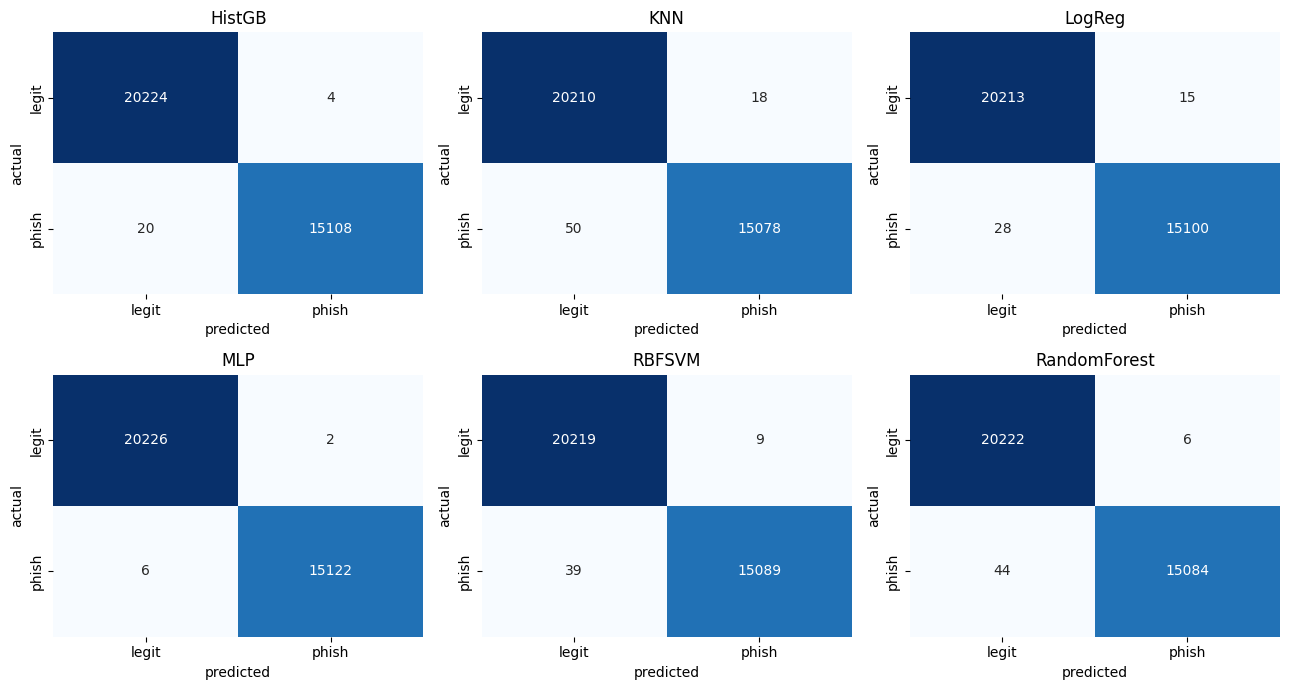

In [ ]:
# confusion matrix per model on the test set (seed 42 predictions)
from sklearn.metrics import confusion_matrix
REF_SEED = SEEDS[0]
model_names = list(agg_mean.index)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, n in zip(axes.ravel(), model_names):
  cm = confusion_matrix(y_test, seeded_preds[(n, REF_SEED)])
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['legit','phish'], yticklabels=['legit','phish'], ax=ax)
  ax.set_title(n)
  ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout()
plt.show()

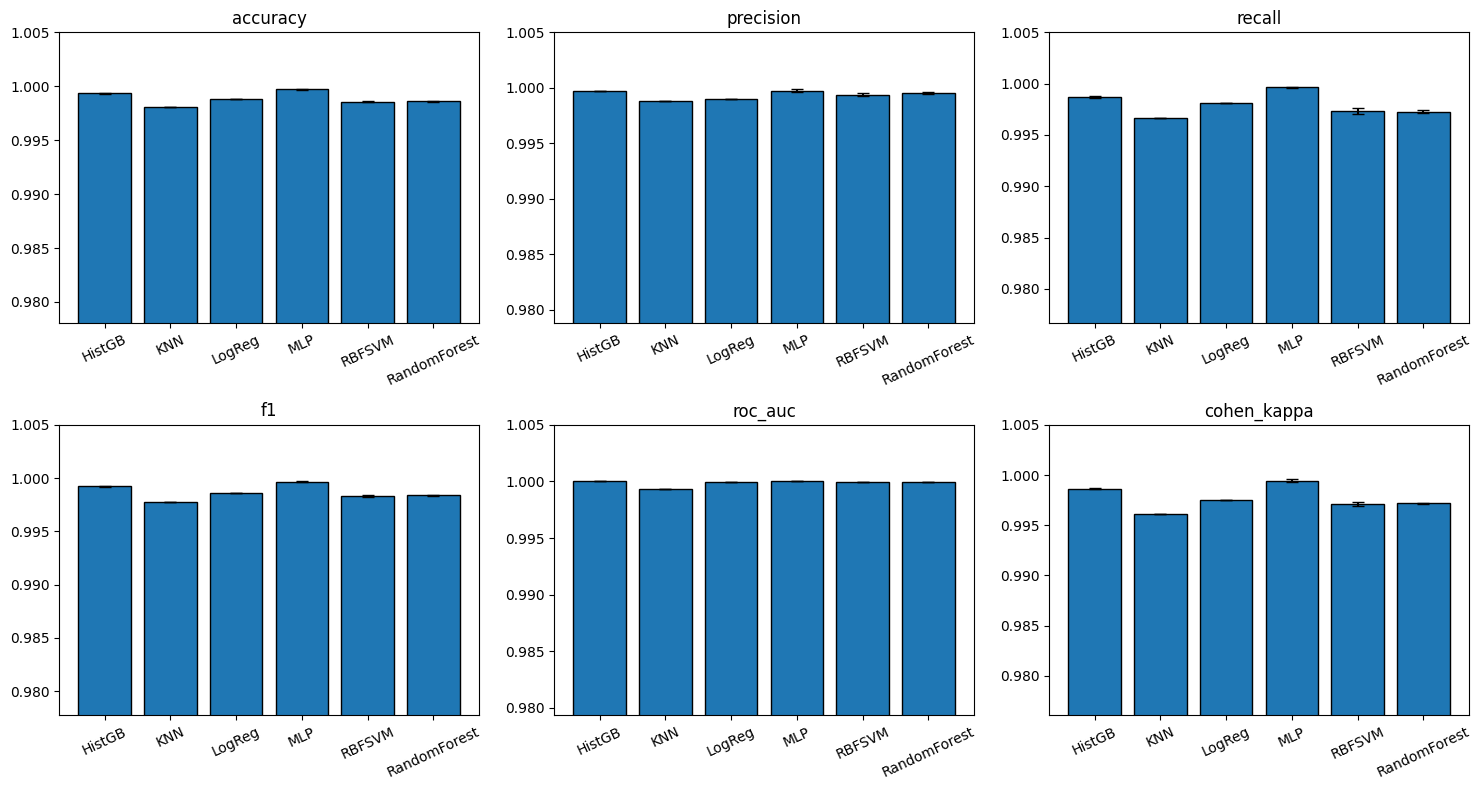

In [ ]:
# bar chart with error bars across seeds, one panel per metric
metrics_for_bars = ['accuracy','precision','recall','f1','roc_auc','cohen_kappa']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.ravel(), metrics_for_bars):
  vals = agg_mean[m].values
  errs = agg_std[m].values
  ax.bar(agg_mean.index, vals, yerr=errs, capsize=4, color='#1f77b4', edgecolor='black')
  ax.set_title(m)
  ax.set_ylim(max(0, vals.min() - 0.02), 1.005)
  ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
# pairwise mcnemar's test on the test set predictions (seed 42).
# null hypothesis: the two models have the same error rate.
# values < 0.05 mean the pair disagrees significantly on which rows it gets wrong.
from scipy.stats import chi2

def mcnemar_p(b_count, c_count):
  if (b_count + c_count) == 0:
    return 1.0
  stat = (abs(b_count - c_count) - 1) ** 2 / (b_count + c_count)
  return 1.0 - chi2.cdf(stat, df=1)

y_te_arr = np.asarray(y_test)
pvals = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for a in model_names:
  for b in model_names:
    if a == b:
      pvals.loc[a, b] = np.nan
      continue
    pa = seeded_preds[(a, REF_SEED)]
    pb = seeded_preds[(b, REF_SEED)]
    correct_a = (pa == y_te_arr)
    correct_b = (pb == y_te_arr)
    only_b = int(np.sum(~correct_a &  correct_b))
    only_a = int(np.sum( correct_a & ~correct_b))
    pvals.loc[a, b] = mcnemar_p(only_b, only_a)

print("pairwise mcnemar p-values (continuity correction, df=1):")
print("entries < 0.05 are significant differences in error patterns.")
pvals.round(5)

pairwise mcnemar p-values (continuity correction, df=1):
entries < 0.05 are significant differences in error patterns.


,HistGB,KNN,LogReg,MLP,RBFSVM,RandomForest
HistGB,NaN,0.00000,0.00605,0.00138,0.00039,0.00001
KNN,0.00000,NaN,0.00337,0.00000,0.00337,0.00871
LogReg,0.00605,0.00337,NaN,0.00000,0.52184,0.39137
MLP,0.00138,0.00000,0.00000,NaN,0.00000,0.00000
RBFSVM,0.00039,0.00337,0.52184,0.00000,NaN,0.85968
RandomForest,0.00001,0.00871,0.39137,0.00000,0.85968,NaN


In [ ]:
# model complexity: parameter count, structural summary, on-disk size in MB
import os, joblib, tempfile

def model_complexity(name, model):
  rec = {'model': name, 'n_params': None, 'structure': None, 'size_mb': None}
  with tempfile.NamedTemporaryFile(delete=False, suffix='.joblib') as tf:
    path = tf.name
  try:
    joblib.dump(model, path)
    rec['size_mb'] = round(os.path.getsize(path) / (1024 * 1024), 3)
  except Exception:
    rec['size_mb'] = None
  finally:
    if os.path.exists(path):
      os.unlink(path)

  if name == 'LogReg':
    rec['n_params'] = int(model.coef_.size + model.intercept_.size)
    rec['structure'] = 'linear (1 weight per feature + bias)'
  elif name == 'RandomForest':
    inner = getattr(model, 'model', model)
    if hasattr(inner, 'estimators_'):
      depths = [t.tree_.max_depth for t in inner.estimators_]
      n_nodes = sum(t.tree_.node_count for t in inner.estimators_)
      rec['n_params'] = int(n_nodes)
      rec['structure'] = f"trees={len(inner.estimators_)}, avg max depth={np.mean(depths):.1f}"
  elif name == 'HistGB':
    iters = getattr(model, 'n_iter_', 0)
    rec['n_params'] = int(iters * 63)
    rec['structure'] = f"iters={iters}, max leaves=63"
  elif name == 'MLP':
    inner = getattr(model, 'model', None)
    if inner is not None:
      rec['n_params'] = int(sum(np.prod(w.shape) for w in inner.get_weights()))
    rec['structure'] = '128 -> 64 -> 32 dense + dropout 0.2'
  elif name == 'RBFSVM':
    inner = getattr(model, 'model', model)
    sv = getattr(inner, 'support_vectors_', None)
    rec['n_params'] = int(sv.size) if sv is not None else None
    rec['structure'] = f"support vectors={getattr(inner, 'support_', np.zeros(0)).shape[0]}"
  elif name == 'KNN':
    inner = getattr(model, 'model', model)
    rec['n_params'] = int(len(y_train))
    rec['structure'] = f"k={getattr(inner, 'n_neighbors', '?')}, stores all training rows"
  return rec

complexity_rows = [model_complexity(n, seeded_models[(n, REF_SEED)]) for n in model_names]
complexity_df = pd.DataFrame(complexity_rows).set_index('model')
print("model complexity (seed 42 fit):")
complexity_df

model complexity (seed 42 fit):


,n_params,structure,size_mb
model,,,
HistGB,8631,"iters=137, max leaves=63",0.988
KNN,164992,"k=6, stores all training rows",47.835
LogReg,38,linear (1 weight per feature + bias),0.001
MLP,15233,128 -> 64 -> 32 dense + dropout 0.2,0.208
RBFSVM,17723,support vectors=479,0.146
RandomForest,91168,"trees=100, avg max depth=23.8",6.994


In [ ]:
# pull everything into one comparison table
INTERPRETABILITY = {
  'LogReg': 'high (signed coefficients, easy to read)',
  'KNN': 'low (instance based, no global rules)',
  'RBFSVM': 'low (kernel space, no direct importance)',
  'MLP': 'low (needs SHAP / permutation importance)',
  'RandomForest': 'medium (feature_importances_, partial deps)',
  'HistGB': 'medium (feature_importances_, SHAP friendly)',
}

comp = pd.DataFrame(index=model_names)
comp['accuracy'] = summary['accuracy']
comp['f1'] = summary['f1']
comp['roc_auc'] = summary['roc_auc']
comp['kappa'] = summary['cohen_kappa']
comp['fit time (s)'] = summary['fit time (s)']
comp['inf ms/sample'] = summary['inf (ms/sample)']
comp['train-test gap'] = summary['train-test acc gap']
comp['n_params'] = complexity_df['n_params']
comp['structure'] = complexity_df['structure']
comp['size_mb'] = complexity_df['size_mb']
comp['interpretability']= [INTERPRETABILITY[n] for n in model_names]
print("model comparison on without_usi (3 seeds):")
comp

model comparison on without_usi (3 seeds):


,accuracy,f1,roc_auc,kappa,fit time (s),inf ms/sample,train-test gap,n_params,structure,size_mb,interpretability
HistGB,0.9993 +/- 0.0000,0.9992 +/- 0.0000,1.0000 +/- 0.0000,0.9987 +/- 0.0001,9.26 +/- 0.93,0.0166 +/- 0.0027,0.00063,8631,"iters=137, max leaves=63",0.988,"medium (feature_importances_, SHAP friendly)"
KNN,0.9981 +/- 0.0000,0.9978 +/- 0.0000,0.9993 +/- 0.0000,0.9961 +/- 0.0000,345.66 +/- 1.29,1.2108 +/- 0.0166,0.00192,164992,"k=6, stores all training rows",47.835,"low (instance based, no global rules)"
LogReg,0.9988 +/- 0.0000,0.9986 +/- 0.0000,1.0000 +/- 0.0000,0.9975 +/- 0.0000,3.03 +/- 0.46,0.0001 +/- 0.0000,0.00000,38,linear (1 weight per feature + bias),0.001,"high (signed coefficients, easy to read)"
MLP,0.9997 +/- 0.0001,0.9997 +/- 0.0001,1.0000 +/- 0.0000,0.9994 +/- 0.0001,65.18 +/- 8.62,0.0853 +/- 0.0532,0.00013,15233,128 -> 64 -> 32 dense + dropout 0.2,0.208,low (needs SHAP / permutation importance)
RBFSVM,0.9986 +/- 0.0001,0.9983 +/- 0.0001,1.0000 +/- 0.0000,0.9971 +/- 0.0002,0.64 +/- 0.05,0.0325 +/- 0.0005,-0.00012,17723,support vectors=479,0.146,"low (kernel space, no direct importance)"
RandomForest,0.9986 +/- 0.0000,0.9984 +/- 0.0000,1.0000 +/- 0.0000,0.9972 +/- 0.0001,159.87 +/- 3.47,0.0103 +/- 0.0048,0.00112,91168,"trees=100, avg max depth=23.8",6.994,"medium (feature_importances_, partial deps)"


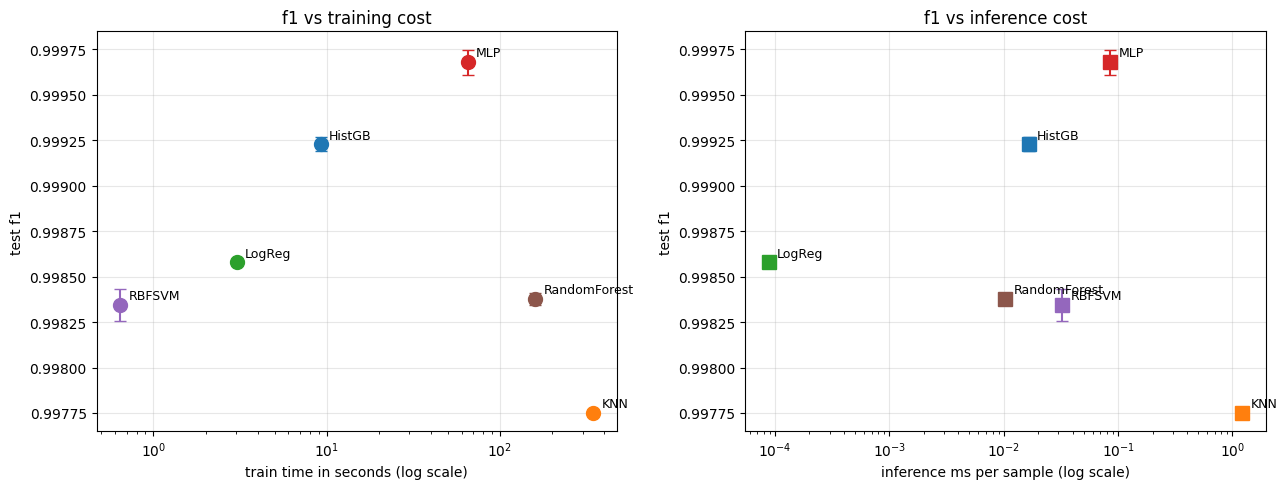

In [ ]:
# scatter plot: f1 vs training cost, then f1 vs inference cost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for n in model_names:
  ax.errorbar(agg_mean.loc[n, 'fit_time_s'], agg_mean.loc[n, 'f1'],
              yerr=agg_std.loc[n, 'f1'], fmt='o', markersize=10, capsize=4)
  ax.annotate(n, (agg_mean.loc[n, 'fit_time_s'], agg_mean.loc[n, 'f1']),
              xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('train time in seconds (log scale)')
ax.set_ylabel('test f1')
ax.set_title('f1 vs training cost')
ax.grid(True, alpha=0.3)

ax = axes[1]
for n in model_names:
  ax.errorbar(agg_mean.loc[n, 'inf_ms_per_sample'], agg_mean.loc[n, 'f1'],
              yerr=agg_std.loc[n, 'f1'], fmt='s', markersize=10, capsize=4)
  ax.annotate(n, (agg_mean.loc[n, 'inf_ms_per_sample'], agg_mean.loc[n, 'f1']),
              xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('inference ms per sample (log scale)')
ax.set_ylabel('test f1')
ax.set_title('f1 vs inference cost')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KNN --> best k = 4 (val F1 = 0.9961)
KNN --> best k = 4 (val F1 = 0.9969)
KNN --> best k = 8 (val F1 = 0.9972)
KNN --> best k = 6 (val F1 = 0.9976)
RF --> best n_estimators = 200 (val F1 = 0.9976)
RF --> best n_estimators = 200 (val F1 = 0.9981)
RF --> best n_estimators = 200 (val F1 = 0.9981)
RF --> best n_estimators = 150 (val F1 = 0.9984)


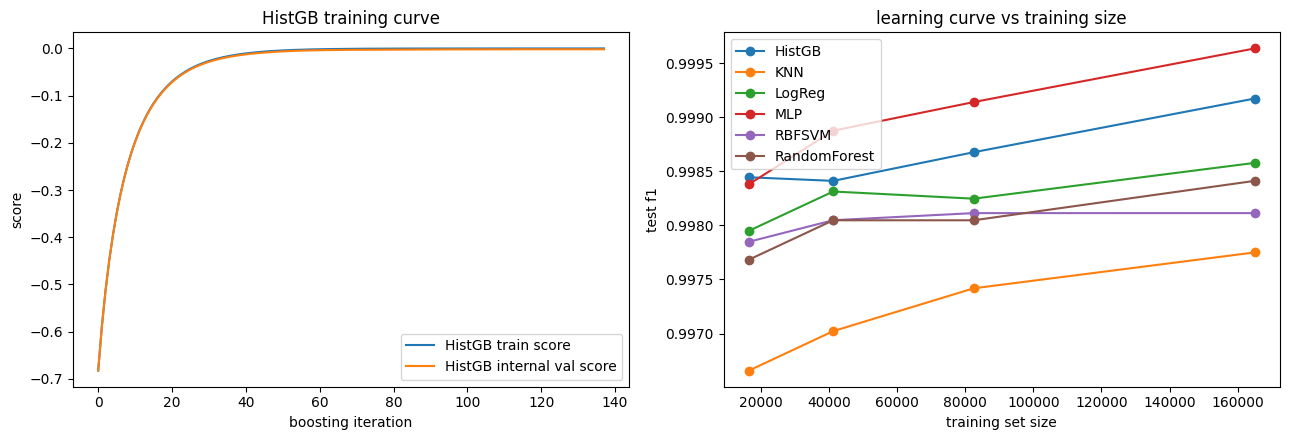

In [ ]:
# learning curves
# left: iteration based curve for HistGB (built in train and val score per iteration)
# right: test f1 vs training set fraction, for the cheaper-to-refit models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
hgb_ref = seeded_models[('HistGB', REF_SEED)]
if hasattr(hgb_ref, 'train_score_'):
  ax.plot(hgb_ref.train_score_, label='HistGB train score')
if hasattr(hgb_ref, 'validation_score_'):
  ax.plot(hgb_ref.validation_score_, label='HistGB internal val score')
ax.set_xlabel('boosting iteration')
ax.set_ylabel('score')
ax.set_title('HistGB training curve')
ax.legend()

ax = axes[1]
fractions = [0.1, 0.25, 0.5, 1.0]
for n in model_names:
  scores = []
  sizes = []
  rng = np.random.default_rng(0)
  for f in fractions:
    n_rows = int(len(X_tr) * f)
    idx = rng.choice(len(X_tr), size=n_rows, replace=False)
    if n in SCALE_DEPENDENT:
      Xs_, Xte_ = X_tr_s[idx], X_te_s
    else:
      Xs_, Xte_ = X_tr[idx], X_te
    yt_ = y_train[idx]
    m = make_models_seeded(42)[n]
    if n in TUNABLE:
      Xv_ = X_va_s if n in SCALE_DEPENDENT else X_va
      m.fit(Xs_, yt_, X_val=Xv_, y_val=y_val)
    else:
      m.fit(Xs_, yt_)
    scores.append(f1_score(y_test, m.predict(Xte_)))
    sizes.append(n_rows)
  ax.plot(sizes, scores, marker='o', label=n)
ax.set_xlabel('training set size')
ax.set_ylabel('test f1')
ax.set_title('learning curve vs training size')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ablation 2: drop engineered fe_* features and see how much f1 falls
# the existing with-USI vs without-USI heatmap from cell 53 is the first ablation.
fe_cols = [c for c in X_tr_fs.columns if c.startswith('fe_')] if hasattr(X_tr_fs, 'columns') else []
print(f"engineered features in this set: {len(fe_cols)}")

abl_rows = []
if len(fe_cols) > 0 and hasattr(X_tr_fs, 'columns'):
  Xtr_no = X_tr_fs.drop(columns=fe_cols).values
  Xva_no = X_va_fs.drop(columns=fe_cols).values
  Xte_no = X_te_fs.drop(columns=fe_cols).values
  scl = StandardScaler().fit(Xtr_no)
  Xtr_no_s = scl.transform(Xtr_no)
  Xva_no_s = scl.transform(Xva_no)
  Xte_no_s = scl.transform(Xte_no)

  for n in model_names:
    m = make_models_seeded(42)[n]
    if n in SCALE_DEPENDENT:
      Xt, Xv, Xs = Xtr_no_s, Xva_no_s, Xte_no_s
    else:
      Xt, Xv, Xs = Xtr_no, Xva_no, Xte_no
    if n in TUNABLE:
      m.fit(Xt, y_train, X_val=Xv, y_val=y_val)
    else:
      m.fit(Xt, y_train)
    yp = m.predict(Xs)
    abl_rows.append({
      'model': n,
      'f1_no_fe':  f1_score(y_test, yp),
      'acc_no_fe': accuracy_score(y_test, yp),
      'f1_with_fe':  agg_mean.loc[n, 'f1'],
      'acc_with_fe': agg_mean.loc[n, 'accuracy'],
    })

abl_df = pd.DataFrame(abl_rows).set_index('model')
abl_df['f1_drop']  = (abl_df['f1_with_fe']  - abl_df['f1_no_fe']).round(4)
abl_df['acc_drop'] = (abl_df['acc_with_fe'] - abl_df['acc_no_fe']).round(4)
print("ablation: removing engineered fe_* features from without_usi:")
abl_df.round(4)

engineered features in this set: 19
KNN --> best k = 4 (val F1 = 0.9977)
RF --> best n_estimators = 150 (val F1 = 0.9985)
ablation: removing engineered fe_* features from without_usi:


,f1_no_fe,acc_no_fe,f1_with_fe,acc_with_fe,f1_drop,acc_drop
model,,,,,,
HistGB,0.9993,0.9994,0.9992,0.9993,-0.0001,-0.0001
KNN,0.9981,0.9984,0.9978,0.9981,-0.0004,-0.0003
LogReg,0.9977,0.9980,0.9986,0.9988,0.0009,0.0008
MLP,0.9997,0.9997,0.9997,0.9997,-0.0000,-0.0000
RBFSVM,0.9983,0.9985,0.9983,0.9986,0.0001,0.0001
RandomForest,0.9985,0.9988,0.9984,0.9986,-0.0002,-0.0001


In [ ]:
# weighted scoring matrix for final model pick
# each axis is normalized to [0, 1] across the candidate models, where 1 is best
WEIGHTS = {'performance': 0.50, 'interpretability': 0.15, 'speed': 0.25, 'generalization': 0.10}

def norm_higher_better(s):
  if s.max() == s.min():
    return pd.Series(1.0, index=s.index)
  return (s - s.min()) / (s.max() - s.min())

def norm_lower_better(s):
  if s.max() == s.min():
    return pd.Series(1.0, index=s.index)
  return (s.max() - s) / (s.max() - s.min())

# ordinal interpretability scores. linear coefs are easiest, tree importances are second,
# kernel SVM and dense MLP need post-hoc tools to explain.
INTERP_SCORE = {'LogReg': 1.0, 'HistGB': 0.6, 'RandomForest': 0.6, 'MLP': 0.2, 'RBFSVM': 0.2, 'KNN': 0.3}

scoring = pd.DataFrame(index=model_names)
scoring['performance'] = norm_higher_better(agg_mean['f1'])
scoring['speed'] = norm_lower_better(agg_mean['inf_ms_per_sample'])
scoring['generalization'] = norm_lower_better((agg_mean['train_acc'] - agg_mean['accuracy']).abs())
scoring['interpretability'] = pd.Series(INTERP_SCORE)

scoring['weighted_total'] = (
  scoring['performance'] * WEIGHTS['performance'] +
  scoring['interpretability'] * WEIGHTS['interpretability'] +
  scoring['speed'] * WEIGHTS['speed'] +
  scoring['generalization'] * WEIGHTS['generalization']
)
scoring = scoring.round(3).sort_values('weighted_total', ascending=False)

print("weighted scoring matrix (perf 0.40, interp 0.20, speed 0.20, gen 0.20):")
print(f"top pick: {scoring.index[0]}\n")
scoring

weighted scoring matrix (perf 0.40, interp 0.20, speed 0.20, gen 0.20):
top pick: MLP



,performance,speed,generalization,interpretability,weighted_total
MLP,1.000,0.930,0.936,0.2,0.813
LogReg,0.429,1.000,1.000,1.0,0.772
HistGB,0.766,0.986,0.676,0.6,0.759
RBFSVM,0.309,0.973,0.939,0.2,0.546
RandomForest,0.326,0.992,0.419,0.6,0.532
KNN,0.000,0.000,0.000,0.3,0.060


In [ ]:
# error analysis on the top-ranked model from the scoring matrix
# inspecting false positives and false negatives, then bin them by URLSimilarityIndex,
# URL length, and HTTPS to see what kinds of inputs the model trips on.
err_model = scoring.index[0]
err_pred = seeded_preds[(err_model, REF_SEED)]
y_te_arr = np.asarray(y_test)

wrong = err_pred != y_te_arr
fp = (err_pred == 1) & (y_te_arr == 0)  # legit flagged as phishing
fn = (err_pred == 0) & (y_te_arr == 1)  # phishing missed

print(f"model: {err_model}")
print(f"errors: {wrong.sum()} / {len(y_te_arr)}  ({wrong.mean()*100:.4f}%)")
print(f"false positives (legit flagged): {fp.sum()}")
print(f"false negatives (phishing missed): {fn.sum()}")

# pull original test rows so we can read raw URLs
test_rows = df_test.reset_index(drop=True)
look_cols = [c for c in ['URL','Domain','TLD','URLLength','NoOfSubDomain','IsHTTPS','URLSimilarityIndex','HasPasswordField','NoOfExternalRef'] if c in test_rows.columns]

print("\nfalse positive samples (up to 10):")
fp_view = test_rows.iloc[np.where(fp)[0][:10]][look_cols]
print(fp_view.to_string(index=False))

print("\nfalse negative samples (up to 10):")
fn_view = test_rows.iloc[np.where(fn)[0][:10]][look_cols]
print(fn_view.to_string(index=False))

model: MLP
errors: 8 / 35356  (0.0226%)
false positives (legit flagged): 2
false negatives (phishing missed): 6

false positive samples (up to 10):
                           URL                 Domain TLD  URLLength  NoOfSubDomain IsHTTPS  URLSimilarityIndex HasPasswordField  NoOfExternalRef
  https://www.joycasino0kz.xyz   www.joycasino0kz.xyz xyz         27              1       1               100.0                0                0
https://www.2020lifestyles.com www.2020lifestyles.com com         29              1       1               100.0                0                4

false negative samples (up to 10):
                                         URL                              Domain TLD  URLLength  NoOfSubDomain IsHTTPS  URLSimilarityIndex HasPasswordField  NoOfExternalRef
https://www.interprocesoswebcancannovil.top/ www.interprocesoswebcancannovil.top top         43              1       1           52.237253                0               18
     http://www.werbeagentur-dig

In [ ]:
# bucket errors by features to see which input slices the model struggles with.
# this gives a categorization of error types instead of looking at single rows.
buckets = pd.DataFrame(index=test_rows.index)
buckets['error_type'] = 'correct'
buckets.loc[fp, 'error_type'] = 'false_positive'
buckets.loc[fn, 'error_type'] = 'false_negative'

if 'URLSimilarityIndex' in test_rows.columns:
  buckets['usi_bin'] = pd.cut(test_rows['URLSimilarityIndex'], bins=[-1, 25, 50, 75, 100], labels=['0-25','25-50','50-75','75-100'])
buckets['url_len_bin'] = pd.cut(test_rows['URLLength'], bins=[0, 25, 50, 100, 1e6], labels=['short','medium','long','very_long'])
if 'IsHTTPS' in test_rows.columns:
  buckets['https'] = test_rows['IsHTTPS'].map({1:'https', 0:'http'})

print("error rate by URLSimilarityIndex bin:")
if 'usi_bin' in buckets.columns:
  print(buckets.groupby('usi_bin')['error_type'].apply(lambda s: (s != 'correct').mean()).round(5))

print("\nerror rate by URL length bin:")
print(buckets.groupby('url_len_bin')['error_type'].apply(lambda s: (s != 'correct').mean()).round(5))

if 'https' in buckets.columns:
  print("\nerror rate by https flag:")
  print(buckets.groupby('https')['error_type'].apply(lambda s: (s != 'correct').mean()).round(5))

print("\nerror counts by type and url length bin:")
print(pd.crosstab(buckets['url_len_bin'], buckets['error_type']))

error rate by URLSimilarityIndex bin:
usi_bin
0-25      0.00000
25-50     0.00000
50-75     0.00069
75-100    0.00018
Name: error_type, dtype: float64

error rate by URL length bin:
url_len_bin
short        0.00007
medium       0.00038
long         0.00000
very_long    0.00000
Name: error_type, dtype: float64

error rate by https flag:
https
http     0.00052
https    0.00014
Name: error_type, dtype: float64

error counts by type and url length bin:
error_type   correct  false_negative  false_positive
url_len_bin                                         
short          13366               1               0
medium         18550               5               2
long            2709               0               0
very_long        723               0               0


/tmp/ipykernel_8287/2002237216.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(buckets.groupby('usi_bin')['error_type'].apply(lambda s: (s != 'correct').mean()).round(5))
/tmp/ipykernel_8287/2002237216.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(buckets.groupby('url_len_bin')['error_type'].apply(lambda s: (s != 'correct').mean()).round(5))
/tmp/ipykernel_8287/2002237216.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

# **SHAP (Isae)**

In [ ]:
!pip install shap

In [ ]:
import joblib
import shap

# Load the best model and its associated components
loaded_artifact = joblib.load('phishing_classifier_best.joblib')

best_model = loaded_artifact['model']
best_scaler = loaded_artifact['scaler']
feature_columns = loaded_artifact['feature_columns']
scale_dependent = loaded_artifact['scale_dependent']

print(f"Loaded model: {type(best_model).__name__}")
print(f"Scale dependent: {scale_dependent}")

Loaded model: KerasMLP
Scale dependent: True


In [ ]:
# Prepare the test data for SHAP explanation
# Use the without_usi test split directly (matches what the best model was trained on)
X_test_shap_df = feature_sets['without_usi'][2]  # DataFrame, unscaled
if hasattr(X_test_shap_df, 'values'):
    X_test_shap_df = X_test_shap_df[feature_columns]  # align column order

X_test_shap = X_test_shap_df.values

# Apply the scaler if the model is scale-dependent
if scale_dependent:
    X_test_shap = best_scaler.transform(X_test_shap)

# Take a subset for SHAP (computationally intensive)
np.random.seed(42)
sample_idx = np.random.choice(X_test_shap.shape[0], 1000, replace=False)
X_test_sample = X_test_shap[sample_idx]
y_test_sample = y_test[sample_idx]

print(f"Shape of X_test_sample for SHAP: {X_test_sample.shape}")

Shape of X_test_sample for SHAP: (1000, 37)


In [ ]:
# Create a SHAP explainer
# For tree-based models, use TreeExplainer. For others, use KernelExplainer (slower)
if hasattr(best_model, 'predict_proba'):
    predict_func = best_model.predict_proba
else:
    predict_func = best_model.predict

explainer = shap.Explainer(predict_func, X_test_sample)

# Calculate SHAP values for the sample
shap_values = explainer(X_test_sample)

print("SHAP values calculated.")

PermutationExplainer explainer: 1001it [37:51,  2.28s/it]

SHAP values calculated.


/tmp/ipykernel_20503/1983798665.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test_sample, feature_names=feature_names, plot_type="dot")


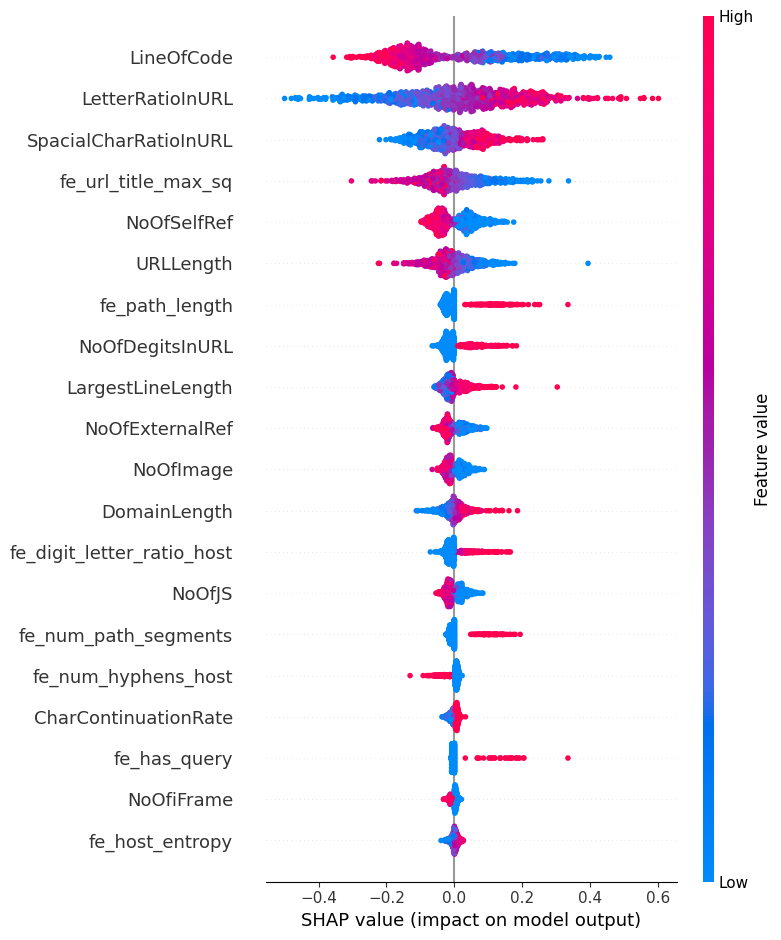

In [ ]:
# Visualize the SHAP summary plot
feature_names = feature_columns if feature_columns is not None else [f'Feature {i}' for i in range(X_test_sample.shape[1])]

shap.summary_plot(shap_values[:, :, 1], X_test_sample, feature_names=feature_names, plot_type="dot")


In [ ]:
import matplotlib.pyplot as plt
import shap

# Redefine X_test_for_shap and y_test_for_shap
X_test_for_shap = feature_sets['without_usi'][2] # This is the unscaled DataFrame for the 'without_usi' feature set
y_test_for_shap = y_test

# Randomly select 1000 indices from the test set for SHAP explanation to speed up computation
# Set random_state for reproducibility
np.random.seed(42)
shap_indices = np.random.choice(X_test_for_shap.shape[0], 1000, replace=False)
X_shap_sample_unscaled = X_test_for_shap.iloc[shap_indices] # Use iloc to get rows from DataFrame
y_shap_sample = y_test_for_shap[shap_indices]

# Get feature names from the unscaled DataFrame for plotting
current_feature_names = X_shap_sample_unscaled.columns.tolist()

# Define a common function to run SHAP analysis for a given model
def run_shap_analysis(model_name, feature_set_name, X_background_unscaled, y_target_sample, feature_names_list, n_kmeans_samples=100):
    print(f"\n--- SHAP analysis for {model_name} on {feature_set_name} ---")

    model = trained_models[(feature_set_name, model_name)]
    scaler = trained_scalers[feature_set_name]
    scale_dependent = model_name in SCALE_DEPENDENT

    # Define a prediction function that handles scaling internally
    def predict_wrapper(X_input):
        X_processed = X_input
        if scale_dependent:

            if isinstance(X_input, pd.DataFrame):
                X_processed = scaler.transform(X_input.values)
            else:
                X_processed = scaler.transform(X_input)

        if hasattr(model, 'predict_proba'):

            return model.predict_proba(X_processed)[:, 1]
        elif hasattr(model, 'decision_function'):

            return model.decision_function(X_processed)
        else:

            return model.predict(X_processed)

    # Use shap.kmeans to summarize the background data
    # This addresses the warning about slow run times for KernelExplainer
    X_background_summary = shap.kmeans(X_background_unscaled.values, n_kmeans_samples)

    explainer = shap.KernelExplainer(predict_wrapper, X_background_summary)

    # Calculate SHAP values for the sampled data
    shap_values = explainer.shap_values(X_background_unscaled.values)

    # Plotting
    print(f"Plotting SHAP summary for {model_name}...")

    shap.summary_plot(shap_values, X_background_unscaled.values, feature_names=feature_names_list, plot_type="dot", show=False)
    plt.title(f'SHAP Summary for {model_name} (Feature Set: {feature_set_name})')
    plt.tight_layout()
    plt.show()

[START] shap

--- SHAP analysis for LogReg on without_usi ---


  0%|          | 0/1000 [00:00<?, ?it/s]

Plotting SHAP summary for LogReg...


/tmp/ipykernel_20503/2730541817.py:58: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_background_unscaled.values, feature_names=feature_names_list, plot_type="dot", show=False)


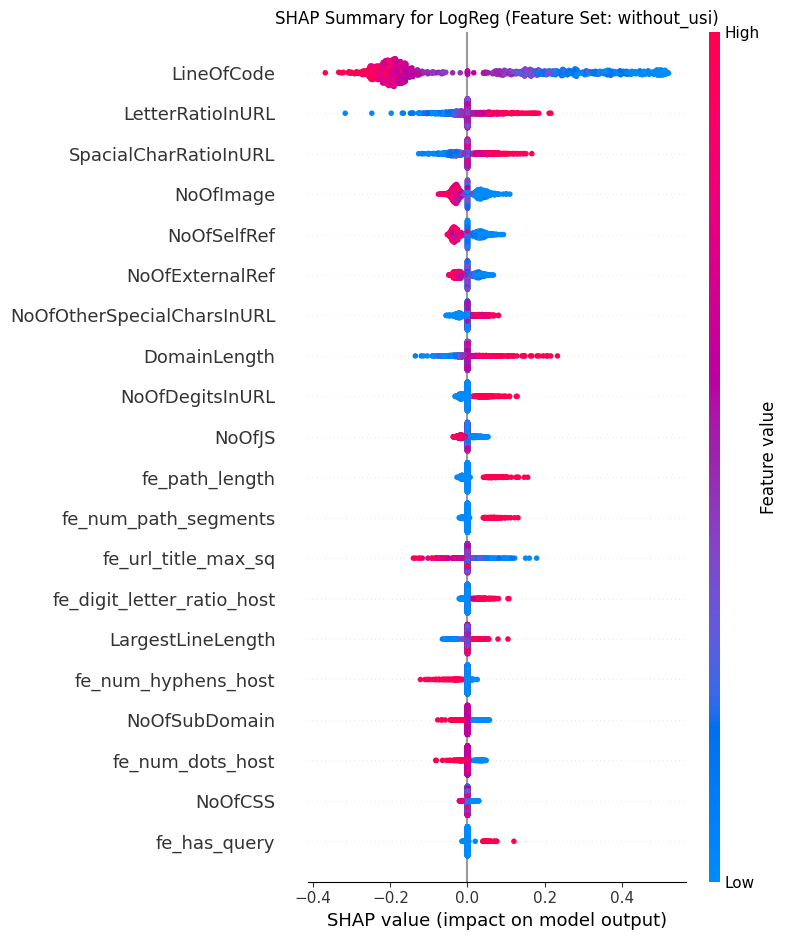


--- SHAP analysis for RBFSVM on without_usi ---


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
section_start("shap")

# Run SHAP for Logistic Regression
run_shap_analysis('LogReg', 'without_usi', X_shap_sample_unscaled, y_shap_sample, current_feature_names)

# Run SHAP for RBFSVM
run_shap_analysis('RBFSVM', 'without_usi', X_shap_sample_unscaled, y_shap_sample, current_feature_names)

section_end("shap")

In [ ]:
# Pipeline latency summary
print("PIPELINE LATENCY SUMMARY")
total = sum(_pipeline_times.values())
for section, t in _pipeline_times.items():
    bar = "█" * int((t / total) * 30)
    print(f"{section:<25} {t:>8.1f}s  {bar}")
print(f"{'TOTAL':<25} {total:>8.1f}s")

PIPELINE LATENCY SUMMARY
data_loading                   0.0s  
data_cleaning                  1.7s  
train_val_test_split           0.8s  
data_transformation            1.8s  
feature_extraction            15.0s  
feature_selection              0.1s  
modeling                     998.9s  █████████████████████████████
--------------------------------------------------
TOTAL                       1018.2s


In [ ]:
import time
print("INFERENCE LATENCY SUMMARY (test set)")
for (fs_name, m_name), model in trained_models.items():
    if fs_name != 'without_usi':  # only measure on realistic feature set
        continue

    fs_test = feature_sets[fs_name][2]
    X_te = fs_test.values if hasattr(fs_test, 'values') else fs_test
    if m_name in SCALE_DEPENDENT:
        X_te = trained_scalers[fs_name].transform(X_te)

    t0 = time.time()
    model.predict(X_te)
    elapsed = time.time() - t0

    n = len(X_te)
    print(f"{m_name:<15} total={elapsed:.3f}s  per_url={elapsed/n*1000:.4f}ms")


INFERENCE LATENCY SUMMARY (test set)
LogReg          total=0.004s  per_url=0.0001ms
RBFSVM          total=1.387s  per_url=0.0392ms
KNN             total=13.491s  per_url=0.3816ms
MLP             total=1.856s  per_url=0.0525ms
RandomForest    total=0.088s  per_url=0.0025ms
HistGB          total=0.149s  per_url=0.0042ms
